
# Task 3 — HAM10000 GNN Improvement, Ablation, Comparison & Explainability
## GNN-only Task 3 workflow — **NO 5-fold cross-validation**

This notebook applies **Task 3 only to the GNN pipeline**.

### What is changed / investigated
- GNN number of layers
- hidden size
- dropout
- BatchNorm
- learning rate
- learning-rate scheduler
- optimizer
- graph-construction method
- edge weighting
- GNN architecture: GCN / GATv2 / GraphSAGE / SuperGAT
- class-imbalance handling
- early stopping
- final GNN selection using **validation Macro-F1**
- final test evaluation
- lesion-level bootstrap 95% confidence intervals
- statistical significance test against the best uploaded baseline
- SHAP + LIME for one correct and one wrong GNN prediction

### What is NOT changed
The four uploaded CNN/Transformer baseline notebooks are **reference baselines only**:
1. ResNet50
2. EfficientNet-B2
3. ViT-B/16
4. Swin-Tiny

No Task-3 ablation, retraining, hyperparameter search, or explainability is applied to those four baselines here.

### No 5-fold GNN CV
The requested 5-fold GNN CV is intentionally omitted to save computation.  
Instead, this notebook uses:
- a fixed, leakage-free lesion-level train/validation/test protocol,
- an untouched final test set,
- lesion-level bootstrap 95% confidence intervals,
- a paired McNemar test **when the best-baseline prediction CSV is available**,
- otherwise a clearly labelled aggregate two-proportion significance fallback.

### Fairness note
The GNN final test split is constructed to match the **15% lesion-level final-test split selected with seed 171** in the uploaded ViT-B/16 and Swin-Tiny notebooks. This makes aggregate final-test comparison with those two baselines substantially more meaningful.

ResNet50 and EfficientNet-B2 used a different 70/15/15 lesion-level split in their uploaded notebooks, so their reported numbers are included as reference values but are marked as **different-test-split** comparisons.



## 0. Kaggle setup

Add the Kaggle dataset:

**Skin Cancer MNIST: HAM10000**

The notebook searches recursively under `/kaggle/input` for `HAM10000_metadata.csv` and image files.

The GNN still follows the image-to-graph idea used in the supplied GNN image sample:

- spatial grid locations are graph nodes,
- normalized row and column coordinates are appended to node features,
- the reference graph uses **up/down/left/right** grid connections,
- self-loops are included,
- graph-level classification uses **global mean pooling**.

For Task-3 graph-construction ablation, an **8-neighbor grid** is tested as the alternative. No superpixel, segmentation, region adjacency, or kNN graph method is introduced.


In [1]:

# Install missing packages only.
import sys
import subprocess
import importlib.util

required_packages = {
    "torch_geometric": "torch-geometric",
    "shap": "shap",
    "lime": "lime",
}

for module_name, pip_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {pip_name} ...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", pip_name]
        )


Installing torch-geometric ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.1 MB/s eta 0:00:00


In [2]:

import os
import gc
import json
import math
import time
import copy
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

from scipy.stats import norm, binomtest

from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import (
    GCNConv,
    GATv2Conv,
    SAGEConv,
    SuperGATConv,
    global_mean_pool,
)

import shap
from lime.lime_tabular import LimeTabularExplainer

print("Imports complete.")
print("PyTorch:", torch.__version__)

try:
    import torch_geometric
    print("PyG:", torch_geometric.__version__)
except Exception:
    pass


Imports complete.
PyTorch: 2.10.0+cu128
PyG: 2.8.0.post1



## 1. Reproducibility and experiment configuration

To save time, the CNN feature encoder is trained **once** and its graph-node features are cached.  
All Task-3 experiments then train only lightweight GNN models.

Every GNN has a maximum of 50 epochs, but early stopping normally finishes much sooner.


In [3]:

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # Deterministic behavior is useful for fair ablation.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

# ------------------------------------------------------------
# Dataset / output paths
# ------------------------------------------------------------
INPUT_ROOT = Path("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000")
OUTPUT_DIR = Path("/kaggle/working/task3_gnn_only")
MODEL_DIR = OUTPUT_DIR / "models"
RESULT_DIR = OUTPUT_DIR / "results"
PLOT_DIR = OUTPUT_DIR / "plots"
EXPLAIN_DIR = OUTPUT_DIR / "explainability"

for folder in [OUTPUT_DIR, MODEL_DIR, RESULT_DIR, PLOT_DIR, EXPLAIN_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# HAM10000
# ------------------------------------------------------------
CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: name for name, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASS_NAMES)

IMAGE_SIZE = 224

# ------------------------------------------------------------
# Fixed ResNet50 feature encoder
# This is NOT part of Task-3 ablation.
# ------------------------------------------------------------
ENCODER_MAX_EPOCHS = 50
ENCODER_WARMUP_EPOCHS = 5
ENCODER_PATIENCE = 8
CNN_BATCH_SIZE = 32

# ------------------------------------------------------------
# GNN Task-3 settings
# ------------------------------------------------------------
GNN_MAX_EPOCHS = 50
GNN_BATCH_SIZE = 64
NUM_WORKERS = 2
SELECTION_METRIC = "macro_f1"

# Set True only if you want to rerun every ablation even when a
# matching saved result already exists.
FORCE_RERUN_ABLATIONS = False

# SHAP/LIME are only for 2 test samples.
SHAP_NSAMPLES = 200
LIME_NUM_SAMPLES = 1000

print("Device:", DEVICE)
print("Output:", OUTPUT_DIR)


Device: cuda
Output: /kaggle/working/task3_gnn_only



## 2. Load HAM10000


Metadata: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Total images: 10015
Unique lesions: 7470


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2


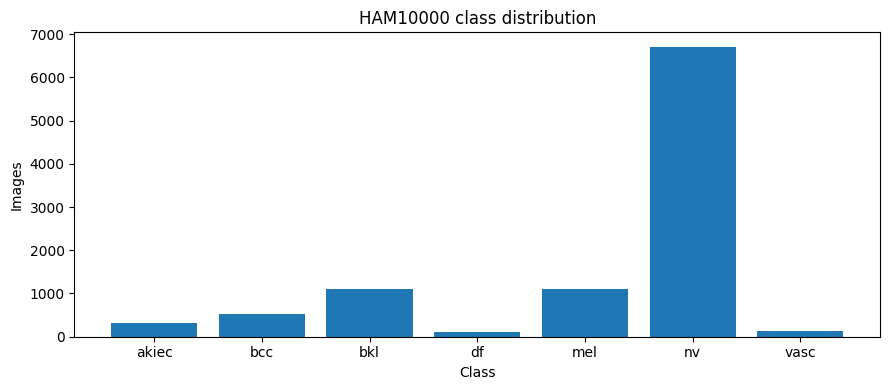

In [4]:

metadata_candidates = list(INPUT_ROOT.rglob("HAM10000_metadata.csv"))

if not metadata_candidates:
    raise FileNotFoundError(
        "HAM10000_metadata.csv was not found under /kaggle/input. "
        "Add the HAM10000 Kaggle dataset first."
    )

META_PATH = metadata_candidates[0]
DATASET_DIR = META_PATH.parent

df = pd.read_csv(META_PATH)

required_columns = {"lesion_id", "image_id", "dx"}
missing = required_columns - set(df.columns)

if missing:
    raise ValueError(f"Missing metadata columns: {missing}")

image_paths = {}

for extension in ("*.jpg", "*.jpeg", "*.JPG", "*.JPEG", "*.png", "*.PNG"):
    for image_path in INPUT_ROOT.rglob(extension):
        image_paths[image_path.stem] = str(image_path)

df["path"] = df["image_id"].astype(str).map(image_paths)
df["label"] = df["dx"].map(CLASS_TO_IDX)

if df["path"].isna().any():
    missing_count = int(df["path"].isna().sum())
    raise FileNotFoundError(
        f"{missing_count} HAM10000 images could not be matched to metadata."
    )

if df["label"].isna().any():
    raise ValueError("Unexpected HAM10000 diagnosis label was found.")

df["label"] = df["label"].astype(int)

print("Metadata:", META_PATH)
print("Total images:", len(df))
print("Unique lesions:", df["lesion_id"].nunique())
display(df.head())

class_counts = df["dx"].value_counts().reindex(CLASS_NAMES)

plt.figure(figsize=(9, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("HAM10000 class distribution")
plt.xlabel("Class")
plt.ylabel("Images")
plt.tight_layout()
plt.show()



## 3. Leakage-free holdout split — NO 5-fold

### Final test set
The uploaded ViT-B/16 and Swin-Tiny notebooks both selected a 15% lesion-level final test split using **seed 171**.  
This notebook reproduces that final test split.

### Train / validation
The remaining development data are split into train and validation groups by `lesion_id`.  
Several candidate group-split seeds are checked, and the split closest to the development-set class distribution is selected.

**The test set is never used for ablation selection.**


In [5]:

# ------------------------------------------------------------
# 15% untouched final test split matching ViT/Swin seed 171
# ------------------------------------------------------------
FINAL_TEST_SIZE = 0.15
FINAL_TEST_SEED = 171

final_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=FINAL_TEST_SIZE,
    random_state=FINAL_TEST_SEED
)

development_idx, test_idx = next(
    final_splitter.split(
        df,
        y=df["label"],
        groups=df["lesion_id"]
    )
)

development_df = df.iloc[development_idx].copy().reset_index(drop=True)
test_df = df.iloc[test_idx].copy().reset_index(drop=True)

# ------------------------------------------------------------
# Split development into ~70% total train and ~15% total val
# ------------------------------------------------------------
VAL_FRACTION_OF_DEVELOPMENT = 0.15 / 0.85

development_distribution = (
    development_df["label"]
    .value_counts(normalize=True)
    .reindex(range(NUM_CLASSES), fill_value=0.0)
)

best_candidate = None
best_score = np.inf

for candidate_seed in range(SEED, SEED + 200):
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=VAL_FRACTION_OF_DEVELOPMENT,
        random_state=candidate_seed
    )

    train_idx_local, val_idx_local = next(
        splitter.split(
            development_df,
            y=development_df["label"],
            groups=development_df["lesion_id"]
        )
    )

    candidate_train = development_df.iloc[train_idx_local]
    candidate_val = development_df.iloc[val_idx_local]

    if set(candidate_train["label"].unique()) != set(range(NUM_CLASSES)):
        continue

    if set(candidate_val["label"].unique()) != set(range(NUM_CLASSES)):
        continue

    val_distribution = (
        candidate_val["label"]
        .value_counts(normalize=True)
        .reindex(range(NUM_CLASSES), fill_value=0.0)
    )

    distribution_error = float(
        np.abs(val_distribution - development_distribution).mean()
    )

    actual_val_fraction = len(candidate_val) / len(df)
    size_error = abs(actual_val_fraction - 0.15)

    score = distribution_error + size_error

    if score < best_score:
        best_score = score
        best_candidate = (
            candidate_seed,
            train_idx_local,
            val_idx_local
        )

if best_candidate is None:
    raise RuntimeError("Could not create a valid lesion-level train/validation split.")

selected_val_seed, train_idx_local, val_idx_local = best_candidate

train_df = development_df.iloc[train_idx_local].copy().reset_index(drop=True)
val_df = development_df.iloc[val_idx_local].copy().reset_index(drop=True)

# ------------------------------------------------------------
# Leakage checks
# ------------------------------------------------------------
train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

assert train_lesions.isdisjoint(val_lesions)
assert train_lesions.isdisjoint(test_lesions)
assert val_lesions.isdisjoint(test_lesions)

train_images = set(train_df["image_id"])
val_images = set(val_df["image_id"])
test_images = set(test_df["image_id"])

assert train_images.isdisjoint(val_images)
assert train_images.isdisjoint(test_images)
assert val_images.isdisjoint(test_images)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "images": [len(train_df), len(val_df), len(test_df)],
    "unique_lesions": [
        train_df["lesion_id"].nunique(),
        val_df["lesion_id"].nunique(),
        test_df["lesion_id"].nunique()
    ],
    "percentage": [
        100 * len(train_df) / len(df),
        100 * len(val_df) / len(df),
        100 * len(test_df) / len(df)
    ]
})

display(split_summary.round(3))

print("Final-test seed:", FINAL_TEST_SEED)
print("Selected validation seed:", selected_val_seed)
print("Lesion leakage check: PASSED")
print("Image leakage check: PASSED")

train_df.to_csv(RESULT_DIR / "train_split.csv", index=False)
val_df.to_csv(RESULT_DIR / "validation_split.csv", index=False)
test_df.to_csv(RESULT_DIR / "final_test_split.csv", index=False)


,split,images,unique_lesions,percentage
0,train,7007,5228,69.965
1,validation,1502,1121,14.998
2,test,1506,1121,15.037


Final-test seed: 171
Selected validation seed: 122
Lesion leakage check: PASSED
Image leakage check: PASSED



## 4. Image transforms and datasets


In [6]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class HAMImageDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image = Image.open(row["path"]).convert("RGB")
        image = self.transform(image)

        return {
            "image": image,
            "label": int(row["label"]),
            "index": index
        }


train_image_ds = HAMImageDataset(train_df, train_transform)
val_image_ds = HAMImageDataset(val_df, eval_transform)
test_image_ds = HAMImageDataset(test_df, eval_transform)

train_image_loader = DataLoader(
    train_image_ds,
    batch_size=CNN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    drop_last=True,  # prevents singleton BatchNorm batch
)

val_image_loader = DataLoader(
    val_image_ds,
    batch_size=CNN_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP
)

test_image_loader = DataLoader(
    test_image_ds,
    batch_size=CNN_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP
)

# Class weights are based only on training data.
raw_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["label"].values
)

# Square-root weighting is less aggressive than raw inverse-frequency weighting.
sqrt_class_weights = np.sqrt(raw_class_weights)
sqrt_class_weights = sqrt_class_weights / sqrt_class_weights.mean()

CLASS_WEIGHTS = torch.tensor(
    sqrt_class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("Training class weights:")
for i, weight in enumerate(sqrt_class_weights):
    print(f"{IDX_TO_CLASS[i]}: {weight:.4f}")


Training class weights:
akiec: 1.1128
bcc: 0.8926
bkl: 0.6095
df: 1.9028
mel: 0.6079
nv: 0.2471
vasc: 1.6274



# Part A — Fixed CNN feature encoder

## 5. Train one ResNet50 feature encoder

This ResNet50 is **not one of the Task-3 ablation targets**.  
It is a fixed feature encoder used to produce the node features for every GNN experiment.

Transfer-learning protocol:
1. ImageNet pretrained ResNet50
2. classifier warm-up
3. unfreeze `layer4`
4. smaller backbone learning rate
5. early stopping

The encoder is trained only once.


In [7]:

class HAMResNet50(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V2
        )

        in_features = self.network.fc.in_features

        self.network.fc = nn.Sequential(
            nn.Dropout(0.50),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.30),
            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        return self.network(x)


def freeze_encoder_for_warmup(model):
    for parameter in model.parameters():
        parameter.requires_grad = False

    for parameter in model.network.fc.parameters():
        parameter.requires_grad = True


def unfreeze_encoder_layer4(model):
    for parameter in model.parameters():
        parameter.requires_grad = False

    for parameter in model.network.layer4.parameters():
        parameter.requires_grad = True

    for parameter in model.network.fc.parameters():
        parameter.requires_grad = True


def set_encoder_train_mode(model, fine_tuning):
    model.train()

    # Frozen early stages remain in evaluation mode.
    model.network.conv1.eval()
    model.network.bn1.eval()
    model.network.layer1.eval()
    model.network.layer2.eval()
    model.network.layer3.eval()

    if not fine_tuning:
        model.network.layer4.eval()


def simple_macro_f1(y_true, y_pred):
    return f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


def run_encoder_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    scaler=None,
    fine_tuning=False
):
    is_train = optimizer is not None

    if is_train:
        set_encoder_train_mode(
            model,
            fine_tuning=fine_tuning
        )
    else:
        model.eval()

    total_loss = 0.0
    n_seen = 0
    all_true = []
    all_pred = []

    for batch in loader:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True
        )

        labels = batch["label"].to(
            DEVICE,
            non_blocking=True
        )

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast(
                device_type=DEVICE.type,
                enabled=USE_AMP
            ):
                logits = model(images)
                loss = criterion(logits, labels)

            if is_train:
                if USE_AMP:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        max_norm=2.0
                    )
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        max_norm=2.0
                    )
                    optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        n_seen += batch_size

        all_true.extend(labels.detach().cpu().numpy())
        all_pred.extend(logits.argmax(dim=1).detach().cpu().numpy())

    metrics = {
        "loss": total_loss / n_seen,
        "accuracy": accuracy_score(all_true, all_pred),
        "macro_f1": simple_macro_f1(all_true, all_pred)
    }

    return metrics


In [8]:

ENCODER_BEST_PATH = MODEL_DIR / "fixed_resnet50_feature_encoder.pt"
ENCODER_HISTORY_PATH = RESULT_DIR / "fixed_encoder_history.csv"

encoder_model = HAMResNet50().to(DEVICE)

if ENCODER_BEST_PATH.exists() and not FORCE_RERUN_ABLATIONS:
    print("Existing fixed encoder checkpoint found.")
    encoder_model.load_state_dict(
        torch.load(
            ENCODER_BEST_PATH,
            map_location=DEVICE
        )
    )

    if ENCODER_HISTORY_PATH.exists():
        encoder_history_df = pd.read_csv(ENCODER_HISTORY_PATH)
    else:
        encoder_history_df = pd.DataFrame()

else:
    criterion = nn.CrossEntropyLoss(
        weight=CLASS_WEIGHTS,
        label_smoothing=0.05
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

    freeze_encoder_for_warmup(encoder_model)

    optimizer = torch.optim.AdamW(
        encoder_model.network.fc.parameters(),
        lr=3e-4,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_val_f1 = -np.inf
    early_counter = 0
    fine_tuning = False
    encoder_history = []

    for epoch in range(1, ENCODER_MAX_EPOCHS + 1):

        if epoch == ENCODER_WARMUP_EPOCHS + 1:
            print("\nStarting fixed-encoder fine-tuning: layer4 unfrozen.")

            fine_tuning = True
            unfreeze_encoder_layer4(encoder_model)

            optimizer = torch.optim.AdamW(
                [
                    {
                        "params": encoder_model.network.layer4.parameters(),
                        "lr": 1e-5
                    },
                    {
                        "params": encoder_model.network.fc.parameters(),
                        "lr": 1e-4
                    }
                ],
                weight_decay=1e-4
            )

            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="max",
                factor=0.5,
                patience=2
            )

            # Give fine-tuning a fresh patience window.
            early_counter = 0

        train_metrics = run_encoder_epoch(
            encoder_model,
            train_image_loader,
            criterion,
            optimizer=optimizer,
            scaler=scaler,
            fine_tuning=fine_tuning
        )

        val_metrics = run_encoder_epoch(
            encoder_model,
            val_image_loader,
            criterion,
            optimizer=None,
            scaler=scaler,
            fine_tuning=fine_tuning
        )

        scheduler.step(val_metrics["macro_f1"])

        record = {
            "epoch": epoch,
            "phase": "fine_tuning" if fine_tuning else "head",
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
        }

        encoder_history.append(record)

        print(
            f"Epoch {epoch:02d}/{ENCODER_MAX_EPOCHS} | "
            f"Train F1 {train_metrics['macro_f1']:.4f} | "
            f"Val F1 {val_metrics['macro_f1']:.4f} | "
            f"Val Acc {val_metrics['accuracy']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1 + 1e-4:
            best_val_f1 = val_metrics["macro_f1"]
            early_counter = 0

            torch.save(
                encoder_model.state_dict(),
                ENCODER_BEST_PATH
            )

            print("Best-Model-saved")
        else:
            if fine_tuning:
                early_counter += 1

        if fine_tuning and early_counter >= ENCODER_PATIENCE:
            print(
                f"Encoder early stopping at epoch {epoch}. "
                f"Best validation Macro-F1: {best_val_f1:.4f}"
            )
            break

    encoder_history_df = pd.DataFrame(encoder_history)
    encoder_history_df.to_csv(
        ENCODER_HISTORY_PATH,
        index=False
    )

    encoder_model.load_state_dict(
        torch.load(
            ENCODER_BEST_PATH,
            map_location=DEVICE
        )
    )

print("Fixed ResNet50 encoder ready.")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


Epoch 01/50 | Train F1 0.2744 | Val F1 0.4030 | Val Acc 0.6764
Best-Model-saved
Epoch 02/50 | Train F1 0.3789 | Val F1 0.4523 | Val Acc 0.7277
Best-Model-saved
Epoch 03/50 | Train F1 0.4115 | Val F1 0.4753 | Val Acc 0.7164
Best-Model-saved
Epoch 04/50 | Train F1 0.4530 | Val F1 0.4305 | Val Acc 0.7264
Epoch 05/50 | Train F1 0.4660 | Val F1 0.4486 | Val Acc 0.7224

Starting fixed-encoder fine-tuning: layer4 unfrozen.
Epoch 06/50 | Train F1 0.4252 | Val F1 0.4531 | Val Acc 0.7124
Epoch 07/50 | Train F1 0.4821 | Val F1 0.4916 | Val Acc 0.7410
Best-Model-saved
Epoch 08/50 | Train F1 0.5257 | Val F1 0.5095 | Val Acc 0.7483
Best-Model-saved
Epoch 09/50 | Train F1 0.5671 | Val F1 0.5331 | Val Acc 0.7590
Best-Model-saved
Epoch 10/50 | Train F1 0.5850 | Val F1 0.5314 | Val Acc 0.7656
Epoch 11/50 | Train F1 0.6092 | Val F1 0.5380 | Val Acc 0.7703
Best-Model-saved
Epoch 12/50 | Train F1 0.6150 | Val F1 0.5735 | Val Acc 0.7823
Best-Model-saved
Epoch 13/50 | Train F1 0.6544 | Val F1 0.5686 | Val Ac


## 6. Extract ResNet50 spatial deep features once

To preserve the original GNN-image pipeline, the node feature map is extracted from:

`layer4[-1].bn2`

For 224×224 input this is normally:

`512 × 7 × 7`

Therefore:
- 49 spatial nodes per image,
- 512 deep features per node,
- plus normalized row and column coordinates,
- total node feature dimension = **514**.

These features are cached so that ablation does not repeatedly run ResNet50.


In [9]:

# Deterministic loaders for feature extraction.
feature_train_ds = HAMImageDataset(train_df, eval_transform)
feature_val_ds = HAMImageDataset(val_df, eval_transform)
feature_test_ds = HAMImageDataset(test_df, eval_transform)

feature_train_loader = DataLoader(
    feature_train_ds,
    batch_size=CNN_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP
)

feature_val_loader = DataLoader(
    feature_val_ds,
    batch_size=CNN_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP
)

feature_test_loader = DataLoader(
    feature_test_ds,
    batch_size=CNN_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP
)


@torch.no_grad()
def extract_spatial_features(
    model,
    loader,
    cache_path
):
    if cache_path.exists() and not FORCE_RERUN_ABLATIONS:
        print("Loading cached graph features:", cache_path)
        return torch.load(cache_path, map_location="cpu")

    model.eval()

    captured = {}

    def hook_fn(module, inputs, output):
        captured["feature_map"] = output.detach()

    handle = model.network.layer4[-1].bn2.register_forward_hook(
        hook_fn
    )

    all_nodes = []
    all_labels = []
    all_indices = []

    grid_h = None
    grid_w = None

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    for batch in loader:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True
        )

        labels = batch["label"]
        indices = batch["index"]

        captured.clear()

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        ):
            _ = model(images)

        fmap = F.relu(
            captured["feature_map"]
        )

        batch_size, channels, h, w = fmap.shape

        if grid_h is None:
            grid_h = h
            grid_w = w

            row_position = torch.tensor(
                [r for r in range(h) for c in range(w)],
                dtype=torch.float32,
                device=fmap.device
            ) / h

            col_position = torch.tensor(
                [c for r in range(h) for c in range(w)],
                dtype=torch.float32,
                device=fmap.device
            ) / w

            position_features = torch.stack(
                [row_position, col_position],
                dim=1
            )

        nodes = (
            fmap
            .permute(0, 2, 3, 1)
            .reshape(batch_size, h * w, channels)
            .float()
        )

        nodes = F.normalize(
            nodes,
            p=2,
            dim=-1
        )

        position_batch = (
            position_features
            .unsqueeze(0)
            .expand(batch_size, -1, -1)
        )

        nodes = torch.cat(
            [nodes, position_batch],
            dim=-1
        )

        all_nodes.append(
            nodes.half().cpu()
        )

        all_labels.append(
            labels.long().cpu()
        )

        all_indices.append(
            indices.long().cpu()
        )

    handle.remove()

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start_time

    output = {
        "x": torch.cat(all_nodes, dim=0),
        "y": torch.cat(all_labels, dim=0),
        "sample_index": torch.cat(all_indices, dim=0),
        "grid_h": int(grid_h),
        "grid_w": int(grid_w),
        "seconds": float(elapsed)
    }

    torch.save(
        output,
        cache_path
    )

    return output


train_feature_obj = extract_spatial_features(
    encoder_model,
    feature_train_loader,
    RESULT_DIR / "train_graph_features.pt"
)

val_feature_obj = extract_spatial_features(
    encoder_model,
    feature_val_loader,
    RESULT_DIR / "validation_graph_features.pt"
)

test_feature_obj = extract_spatial_features(
    encoder_model,
    feature_test_loader,
    RESULT_DIR / "test_graph_features.pt"
)

X_TRAIN = train_feature_obj["x"]
Y_TRAIN = train_feature_obj["y"]

X_VAL = val_feature_obj["x"]
Y_VAL = val_feature_obj["y"]

X_TEST = test_feature_obj["x"]
Y_TEST = test_feature_obj["y"]

GRID_H = train_feature_obj["grid_h"]
GRID_W = train_feature_obj["grid_w"]
NODE_FEATURE_DIM = X_TRAIN.shape[-1]
DEEP_FEATURE_DIM = NODE_FEATURE_DIM - 2

print("Train:", X_TRAIN.shape)
print("Validation:", X_VAL.shape)
print("Test:", X_TEST.shape)
print(f"Graph grid: {GRID_H} x {GRID_W}")
print("Nodes/image:", GRID_H * GRID_W)
print("Node feature dimension:", NODE_FEATURE_DIM)


Train: torch.Size([7007, 49, 514])
Validation: torch.Size([1502, 49, 514])
Test: torch.Size([1506, 49, 514])
Graph grid: 7 x 7
Nodes/image: 49
Node feature dimension: 514



# Part B — Graph construction

## 7. Reference and ablation graph methods

### `grid4`
Reference graph:
- up
- down
- left
- right
- self-loop

### `grid8`
Task-3 graph-construction ablation:
- grid4 edges
- four diagonal neighbors
- self-loop

### Edge-weight ablation
When enabled, edge similarity is calculated from the deep CNN node features using cosine similarity mapped to `[0,1]`.

- GCN uses it as `edge_weight`
- GATv2 uses it as a scalar `edge_attr`
- GraphSAGE and SuperGAT do not natively use the same scalar weight in this implementation, and this is recorded as a limitation.


In [10]:

def node_id(row, col, width):
    return row * width + col


def build_grid_edge_index(
    height,
    width,
    method="grid4",
    include_self_loops=True
):
    if method not in {"grid4", "grid8"}:
        raise ValueError("method must be 'grid4' or 'grid8'")

    undirected_offsets = [
        (1, 0),
        (0, 1),
    ]

    if method == "grid8":
        undirected_offsets.extend([
            (1, 1),
            (1, -1),
        ])

    edges = []

    for row in range(height):
        for col in range(width):
            source = node_id(row, col, width)

            for dr, dc in undirected_offsets:
                nr = row + dr
                nc = col + dc

                if 0 <= nr < height and 0 <= nc < width:
                    target = node_id(nr, nc, width)
                    edges.append((source, target))
                    edges.append((target, source))

            if include_self_loops:
                edges.append((source, source))

    return (
        torch.tensor(
            edges,
            dtype=torch.long
        )
        .t()
        .contiguous()
    )


EDGE_INDEX_BY_METHOD = {
    "grid4": build_grid_edge_index(
        GRID_H,
        GRID_W,
        method="grid4",
        include_self_loops=True
    ),
    "grid8": build_grid_edge_index(
        GRID_H,
        GRID_W,
        method="grid8",
        include_self_loops=True
    )
}

for graph_name, edge_index in EDGE_INDEX_BY_METHOD.items():
    print(
        graph_name,
        "| nodes:", GRID_H * GRID_W,
        "| directed edges:", edge_index.shape[1]
    )


grid4 | nodes: 49 | directed edges: 217
grid8 | nodes: 49 | directed edges: 361


In [11]:

class GraphFeatureDataset(Dataset):
    def __init__(
        self,
        node_features,
        labels,
        edge_index
    ):
        self.node_features = node_features
        self.labels = labels
        self.edge_index = edge_index

    def __len__(self):
        return self.labels.numel()

    def __getitem__(self, index):
        return Data(
            x=self.node_features[index].float(),
            edge_index=self.edge_index,
            y=self.labels[index].view(1),
            sample_idx=torch.tensor(
                [index],
                dtype=torch.long
            )
        )


GRAPH_LOADER_CACHE = {}


def get_graph_loaders(graph_method):
    if graph_method in GRAPH_LOADER_CACHE:
        return GRAPH_LOADER_CACHE[graph_method]

    edge_index = EDGE_INDEX_BY_METHOD[graph_method]

    train_dataset = GraphFeatureDataset(
        X_TRAIN,
        Y_TRAIN,
        edge_index
    )

    val_dataset = GraphFeatureDataset(
        X_VAL,
        Y_VAL,
        edge_index
    )

    test_dataset = GraphFeatureDataset(
        X_TEST,
        Y_TEST,
        edge_index
    )

    loaders = {
        "train": GeoDataLoader(
            train_dataset,
            batch_size=GNN_BATCH_SIZE,
            shuffle=True,
            num_workers=0,
            pin_memory=USE_AMP
        ),
        "val": GeoDataLoader(
            val_dataset,
            batch_size=GNN_BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            pin_memory=USE_AMP
        ),
        "test": GeoDataLoader(
            test_dataset,
            batch_size=GNN_BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            pin_memory=USE_AMP
        )
    }

    GRAPH_LOADER_CACHE[graph_method] = loaders
    return loaders



# Part C — Configurable GNNs and training utilities

## 8. GCN / GATv2 / GraphSAGE / SuperGAT

All variants use the same:
- ResNet50 spatial node features,
- positional features,
- graph-level mean pooling,
- seven-class output.

Only the GNN itself is varied.


In [12]:

class FocalLoss(nn.Module):
    def __init__(
        self,
        alpha=None,
        gamma=2.0
    ):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)

        focal_loss = (
            (1 - pt) ** self.gamma
        ) * ce_loss

        return focal_loss.mean()


def create_loss_function(name):
    if name == "weighted_ce":
        return nn.CrossEntropyLoss(
            weight=CLASS_WEIGHTS,
            label_smoothing=0.05
        )

    if name == "focal":
        return FocalLoss(
            alpha=CLASS_WEIGHTS,
            gamma=2.0
        )

    if name == "plain_ce":
        return nn.CrossEntropyLoss(
            label_smoothing=0.05
        )

    raise ValueError(
        f"Unknown imbalance/loss method: {name}"
    )


class FlexibleGNN(nn.Module):
    def __init__(
        self,
        in_features,
        num_classes,
        variant="gatv2",
        num_layers=3,
        hidden_size=128,
        dropout=0.4,
        batch_norm=True,
        edge_weights=False,
        heads=4
    ):
        super().__init__()

        self.variant = variant.lower()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.dropout = dropout
        self.use_batch_norm = batch_norm
        self.use_edge_weights = edge_weights
        self.heads = heads

        if self.variant in {"gatv2", "supergat"}:
            if hidden_size % heads != 0:
                raise ValueError(
                    "hidden_size must be divisible by heads "
                    "for attention models."
                )

        self.input_projection = nn.Linear(
            in_features,
            hidden_size
        )

        self.input_norm = (
            nn.BatchNorm1d(hidden_size)
            if batch_norm
            else nn.Identity()
        )

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):

            if self.variant == "gcn":
                conv = GCNConv(
                    hidden_size,
                    hidden_size,
                    add_self_loops=False
                )

            elif self.variant == "gatv2":
                conv = GATv2Conv(
                    hidden_size,
                    hidden_size // heads,
                    heads=heads,
                    concat=True,
                    dropout=dropout,
                    add_self_loops=False,
                    edge_dim=1 if edge_weights else None
                )

            elif self.variant == "graphsage":
                conv = SAGEConv(
                    hidden_size,
                    hidden_size
                )

            elif self.variant == "supergat":
                conv = SuperGATConv(
                    hidden_size,
                    hidden_size // heads,
                    heads=heads,
                    concat=True,
                    dropout=dropout,
                    add_self_loops=False,
                    attention_type="MX",
                    neg_sample_ratio=0.5,
                    edge_sample_ratio=1.0,
                    is_undirected=True
                )

            else:
                raise ValueError(
                    f"Unknown GNN variant: {variant}"
                )

            self.convs.append(conv)

            self.norms.append(
                nn.BatchNorm1d(hidden_size)
                if batch_norm
                else nn.Identity()
            )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, num_classes)
        )

    def calculate_edge_similarity(
        self,
        original_x,
        edge_index
    ):
        source = edge_index[0]
        target = edge_index[1]

        deep_x = original_x[
            :,
            :DEEP_FEATURE_DIM
        ]

        similarity = F.cosine_similarity(
            deep_x[source],
            deep_x[target],
            dim=1,
            eps=1e-8
        )

        # map cosine [-1, 1] to [0, 1]
        similarity = (
            (similarity + 1.0) / 2.0
        ).clamp(0.0, 1.0)

        return similarity

    def forward(
        self,
        x,
        edge_index,
        batch
    ):
        original_x = x

        edge_similarity = None

        if self.use_edge_weights:
            edge_similarity = (
                self.calculate_edge_similarity(
                    original_x,
                    edge_index
                )
            )

        x = self.input_projection(x)
        x = self.input_norm(x)
        x = F.relu(x)
        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        for conv, norm in zip(
            self.convs,
            self.norms
        ):
            residual = x

            if self.variant == "gcn":
                x = conv(
                    x,
                    edge_index,
                    edge_weight=(
                        edge_similarity
                        if self.use_edge_weights
                        else None
                    )
                )

            elif self.variant == "gatv2":
                x = conv(
                    x,
                    edge_index,
                    edge_attr=(
                        edge_similarity.unsqueeze(-1)
                        if self.use_edge_weights
                        else None
                    )
                )

            elif self.variant == "graphsage":
                # Scalar edge weights are not used by SAGEConv.
                x = conv(
                    x,
                    edge_index
                )

            elif self.variant == "supergat":
                # SuperGAT uses its own attention/self-supervision.
                x = conv(
                    x,
                    edge_index,
                    batch=batch
                )

            x = norm(x)
            x = F.elu(x)

            # Residual connection helps deeper GNN stability.
            x = x + residual

            x = F.dropout(
                x,
                p=self.dropout,
                training=self.training
            )

        graph_embedding = global_mean_pool(
            x,
            batch
        )

        return self.classifier(
            graph_embedding
        )

    def auxiliary_loss(self):
        if (
            self.variant != "supergat"
            or not self.training
        ):
            return torch.tensor(
                0.0,
                device=next(self.parameters()).device
            )

        losses = [
            conv.get_attention_loss()
            for conv in self.convs
        ]

        return torch.stack(losses).sum()


In [13]:

def calculate_metrics(
    y_true,
    y_pred,
    y_prob=None
):
    metrics = {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "macro_precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
    }

    if y_prob is not None:
        try:
            metrics["macro_auc"] = roc_auc_score(
                y_true,
                y_prob,
                labels=np.arange(NUM_CLASSES),
                multi_class="ovr",
                average="macro"
            )
        except ValueError:
            metrics["macro_auc"] = np.nan
    else:
        metrics["macro_auc"] = np.nan

    return metrics


def run_graph_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    aux_weight=0.01
):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_graphs = 0

    all_true = []
    all_pred = []
    all_prob = []
    all_indices = []

    for batch in loader:
        batch = batch.to(DEVICE)
        labels = batch.y.view(-1)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(
                batch.x,
                batch.edge_index,
                batch.batch
            )

            classification_loss = criterion(
                logits,
                labels
            )

            loss = (
                classification_loss
                + aux_weight
                * model.auxiliary_loss()
            )

            if is_train:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=2.0
                )

                optimizer.step()

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = probabilities.argmax(
            dim=1
        )

        n_graphs = labels.numel()

        total_loss += loss.item() * n_graphs
        total_graphs += n_graphs

        all_true.extend(
            labels.detach().cpu().numpy()
        )

        all_pred.extend(
            predictions.detach().cpu().numpy()
        )

        all_prob.extend(
            probabilities.detach().cpu().numpy()
        )

        all_indices.extend(
            batch.sample_idx.view(-1)
            .detach()
            .cpu()
            .numpy()
        )

    metrics = calculate_metrics(
        np.asarray(all_true),
        np.asarray(all_pred),
        np.asarray(all_prob)
    )

    metrics["loss"] = total_loss / total_graphs

    return {
        "metrics": metrics,
        "y_true": np.asarray(all_true),
        "y_pred": np.asarray(all_pred),
        "y_prob": np.asarray(all_prob),
        "sample_idx": np.asarray(all_indices)
    }


def create_optimizer(
    model,
    name,
    learning_rate
):
    if name == "adamw":
        return torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=5e-4
        )

    if name == "adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=5e-4
        )

    raise ValueError(
        f"Unknown optimizer: {name}"
    )


def create_scheduler(
    optimizer,
    name,
    max_epochs
):
    if name == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2
        )

    if name == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max_epochs
        )

    if name == "none":
        return None

    raise ValueError(
        f"Unknown scheduler: {name}"
    )



## 9. Single GNN experiment function

**Important:**  
Ablation decisions use only **validation Macro-F1**.  
The final test set is not touched until the final configuration has been selected.


In [14]:

EXPERIMENT_CACHE = {}


def config_key(config):
    normalized = json.dumps(
        config,
        sort_keys=True
    )

    return hashlib.md5(
        normalized.encode("utf-8")
    ).hexdigest()[:12]


def train_gnn_experiment(
    config,
    run_name=None,
    force=False
):
    config = copy.deepcopy(config)
    key = config_key(config)

    if run_name is None:
        run_name = f"exp_{key}"

    checkpoint_path = (
        MODEL_DIR
        / f"{run_name}_{key}.pt"
    )

    history_path = (
        RESULT_DIR
        / f"{run_name}_{key}_history.csv"
    )

    summary_path = (
        RESULT_DIR
        / f"{run_name}_{key}_summary.json"
    )

    if (
        key in EXPERIMENT_CACHE
        and not force
    ):
        return EXPERIMENT_CACHE[key]

    # Make each configuration comparison start from
    # the same random state.
    seed_everything(SEED)

    loaders = get_graph_loaders(
        config["graph_method"]
    )

    model = FlexibleGNN(
        in_features=NODE_FEATURE_DIM,
        num_classes=NUM_CLASSES,
        variant=config["variant"],
        num_layers=config["num_layers"],
        hidden_size=config["hidden_size"],
        dropout=config["dropout"],
        batch_norm=config["batch_norm"],
        edge_weights=config["edge_weights"],
        heads=config.get("heads", 4)
    ).to(DEVICE)

    criterion = create_loss_function(
        config["imbalance"]
    )

    optimizer = create_optimizer(
        model,
        config["optimizer"],
        config["lr"]
    )

    scheduler = create_scheduler(
        optimizer,
        config["scheduler"],
        GNN_MAX_EPOCHS
    )

    best_val_f1 = -np.inf
    best_val_auc = -np.inf
    best_epoch = -1
    early_counter = 0

    history = []

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    for epoch in range(
        1,
        GNN_MAX_EPOCHS + 1
    ):
        train_result = run_graph_epoch(
            model,
            loaders["train"],
            criterion,
            optimizer=optimizer,
            aux_weight=0.01
        )

        val_result = run_graph_epoch(
            model,
            loaders["val"],
            criterion,
            optimizer=None,
            aux_weight=0.01
        )

        train_metrics = train_result["metrics"]
        val_metrics = val_result["metrics"]

        if scheduler is not None:
            if config["scheduler"] == "plateau":
                scheduler.step(
                    val_metrics["macro_f1"]
                )
            else:
                scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_macro_auc": val_metrics["macro_auc"],
            "learning_rate": current_lr
        })

        current_f1 = val_metrics["macro_f1"]

        current_auc = (
            val_metrics["macro_auc"]
            if np.isfinite(val_metrics["macro_auc"])
            else -np.inf
        )

        improved = (
            current_f1 > best_val_f1 + 1e-4
            or (
                abs(current_f1 - best_val_f1) <= 1e-4
                and current_auc > best_val_auc
            )
        )

        if improved:
            best_val_f1 = current_f1
            best_val_auc = current_auc
            best_epoch = epoch
            early_counter = 0

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "config": config,
                    "best_epoch": best_epoch,
                    "best_val_macro_f1": best_val_f1,
                    "best_val_macro_auc": best_val_auc
                },
                checkpoint_path
            )

            print("Best-Model-saved")
        else:
            early_counter += 1

        print(
            f"{run_name} | "
            f"Epoch {epoch:02d}/{GNN_MAX_EPOCHS} | "
            f"Train F1 {train_metrics['macro_f1']:.4f} | "
            f"Val F1 {val_metrics['macro_f1']:.4f} | "
            f"Val Acc {val_metrics['accuracy']:.4f}"
        )

        if early_counter >= config["patience"]:
            print(
                f"Early stopping: epoch {epoch}; "
                f"best epoch {best_epoch}."
            )
            break

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    training_seconds = (
        time.perf_counter()
        - start_time
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    final_val_result = run_graph_epoch(
        model,
        loaders["val"],
        criterion,
        optimizer=None,
        aux_weight=0.01
    )

    final_val_metrics = final_val_result[
        "metrics"
    ]

    history_df = pd.DataFrame(history)
    history_df.to_csv(
        history_path,
        index=False
    )

    summary = {
        "run_name": run_name,
        "config_key": key,
        **config,
        "best_epoch": int(best_epoch),
        "training_seconds": float(training_seconds),
        "val_accuracy": float(
            final_val_metrics["accuracy"]
        ),
        "val_balanced_accuracy": float(
            final_val_metrics["balanced_accuracy"]
        ),
        "val_macro_precision": float(
            final_val_metrics["macro_precision"]
        ),
        "val_macro_recall": float(
            final_val_metrics["macro_recall"]
        ),
        "val_macro_f1": float(
            final_val_metrics["macro_f1"]
        ),
        "val_weighted_f1": float(
            final_val_metrics["weighted_f1"]
        ),
        "val_macro_auc": (
            None
            if not np.isfinite(
                final_val_metrics["macro_auc"]
            )
            else float(
                final_val_metrics["macro_auc"]
            )
        ),
        "checkpoint_path": str(
            checkpoint_path
        ),
        "history_path": str(
            history_path
        ),
        "effective_edge_weighting": (
            bool(config["edge_weights"])
            and config["variant"]
            in {"gcn", "gatv2"}
        )
    }

    with open(
        summary_path,
        "w"
    ) as file:
        json.dump(
            summary,
            file,
            indent=4
        )

    result = {
        "summary": summary,
        "config": config,
        "checkpoint_path": checkpoint_path,
        "history_path": history_path
    }

    EXPERIMENT_CACHE[key] = result

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result



# Part D — Task-3 sequential ablation

## 10. Initial GNN configuration

This is the **Task-3 first/reference GNN**.  
All later improvements are compared against it using the same leakage-free split and fixed CNN node features.

A sequential ablation is used instead of a full Cartesian grid search to save time.

At each stage:
1. only one factor is varied,
2. the current best configuration is reused,
3. the winner is chosen by validation Macro-F1,
4. the test set remains untouched.


In [15]:

INITIAL_GNN_CONFIG = {
    "variant": "gatv2",
    "num_layers": 3,
    "hidden_size": 128,
    "dropout": 0.40,
    "batch_norm": True,
    "lr": 2e-4,
    "scheduler": "plateau",
    "optimizer": "adamw",
    "graph_method": "grid4",
    "edge_weights": False,
    "imbalance": "weighted_ce",
    "patience": 10,
    "heads": 4
}

print(
    json.dumps(
        INITIAL_GNN_CONFIG,
        indent=4
    )
)


{
    "variant": "gatv2",
    "num_layers": 3,
    "hidden_size": 128,
    "dropout": 0.4,
    "batch_norm": true,
    "lr": 0.0002,
    "scheduler": "plateau",
    "optimizer": "adamw",
    "graph_method": "grid4",
    "edge_weights": false,
    "imbalance": "weighted_ce",
    "patience": 10,
    "heads": 4
}


In [17]:

# ============================================================
# FIX PyTorch UnpicklingError + RUN INITIAL GATv2
# ============================================================

import os

# Kaggle / PyTorch 2.6+ compatibility fix.
# Our checkpoint contains:
# model_state_dict + config + epoch + metrics
# so it must be loaded with weights_only=False.
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

print("PyTorch checkpoint compatibility fix applied.")
print("Starting Initial GATv2 training...")

# Train the initial/reference GATv2 once.
initial_result = train_gnn_experiment(
    INITIAL_GNN_CONFIG,
    run_name="initial_gatv2",
    force=FORCE_RERUN_ABLATIONS
)

# Show result
initial_summary_df = pd.DataFrame([
    initial_result["summary"]
])

display(initial_summary_df)

print("\nInitial GATv2 completed successfully.")


PyTorch checkpoint compatibility fix applied.
Starting Initial GATv2 training...
Best-Model-saved
initial_gatv2 | Epoch 01/50 | Train F1 0.1521 | Val F1 0.2224 | Val Acc 0.6951
Best-Model-saved
initial_gatv2 | Epoch 02/50 | Train F1 0.2790 | Val F1 0.3064 | Val Acc 0.6738
Best-Model-saved
initial_gatv2 | Epoch 03/50 | Train F1 0.3819 | Val F1 0.4078 | Val Acc 0.6891
Best-Model-saved
initial_gatv2 | Epoch 04/50 | Train F1 0.4951 | Val F1 0.4483 | Val Acc 0.6897
Best-Model-saved
initial_gatv2 | Epoch 05/50 | Train F1 0.5708 | Val F1 0.4530 | Val Acc 0.6851
Best-Model-saved
initial_gatv2 | Epoch 06/50 | Train F1 0.6149 | Val F1 0.4625 | Val Acc 0.6884
Best-Model-saved
initial_gatv2 | Epoch 07/50 | Train F1 0.6244 | Val F1 0.5070 | Val Acc 0.7170
initial_gatv2 | Epoch 08/50 | Train F1 0.6573 | Val F1 0.4988 | Val Acc 0.7137
initial_gatv2 | Epoch 09/50 | Train F1 0.6749 | Val F1 0.5069 | Val Acc 0.7097
initial_gatv2 | Epoch 10/50 | Train F1 0.6931 | Val F1 0.4868 | Val Acc 0.6951
Best-Model

/tmp/ipykernel_58/47617162.py:200: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  checkpoint = torch.load(


,run_name,config_key,variant,num_layers,hidden_size,dropout,batch_norm,lr,scheduler,optimizer,...,val_accuracy,val_balanced_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1,val_macro_auc,checkpoint_path,history_path,effective_edge_weighting
0,initial_gatv2,774c9debc983,gatv2,3,128,0.4,True,0.0002,plateau,adamw,...,0.723702,0.621322,0.50339,0.621322,0.544281,0.739379,0.890634,/kaggle/working/task3_gnn_only/models/initial_...,/kaggle/working/task3_gnn_only/results/initial...,False



Initial GATv2 completed successfully.



## 11. Automated time-saving ablation

The notebook tests all requested Task-3 GNN factors without performing an expensive full hyperparameter grid.

Stages:
1. layers
2. hidden size
3. dropout
4. BatchNorm
5. learning rate
6. scheduler
7. optimizer
8. graph construction
9. edge weights
10. GNN variant
11. imbalance handling
12. early-stopping patience


In [18]:

ABLATION_STAGES = [
    {
        "stage": "layers",
        "parameter": "num_layers",
        "values": [2, 3]
    },
    {
        "stage": "hidden_size",
        "parameter": "hidden_size",
        "values": [64, 128]
    },
    {
        "stage": "dropout",
        "parameter": "dropout",
        "values": [0.30, 0.40, 0.50]
    },
    {
        "stage": "batch_norm",
        "parameter": "batch_norm",
        "values": [True, False]
    },
    {
        "stage": "learning_rate",
        "parameter": "lr",
        "values": [2e-4, 5e-4]
    },
    {
        "stage": "lr_scheduler",
        "parameter": "scheduler",
        "values": ["plateau", "cosine"]
    },
    {
        "stage": "optimizer",
        "parameter": "optimizer",
        "values": ["adamw", "adam"]
    },
    {
        "stage": "graph_construction",
        "parameter": "graph_method",
        "values": ["grid4", "grid8"]
    },
    {
        "stage": "edge_weights",
        "parameter": "edge_weights",
        "values": [False, True]
    },
    {
        "stage": "gnn_variant",
        "parameter": "variant",
        "values": [
            "gatv2",
            "gcn",
            "graphsage",
            "supergat"
        ]
    },
    {
        "stage": "imbalance_handling",
        "parameter": "imbalance",
        "values": [
            "weighted_ce",
            "focal"
        ]
    },
    {
        "stage": "early_stopping",
        "parameter": "patience",
        "values": [5, 10]
    }
]


current_best_config = copy.deepcopy(
    INITIAL_GNN_CONFIG
)

ablation_records = []

# Include the original/reference row.
reference_summary = copy.deepcopy(
    initial_result["summary"]
)

reference_summary["ablation_stage"] = "reference"
reference_summary["varied_parameter"] = "none"
reference_summary["candidate_value"] = "initial"

ablation_records.append(
    reference_summary
)


for stage_number, stage in enumerate(
    ABLATION_STAGES,
    start=1
):
    print("\n" + "=" * 90)
    print(
        f"ABLATION STAGE {stage_number}: "
        f"{stage['stage']}"
    )
    print("=" * 90)

    stage_candidates = []

    for candidate_value in stage["values"]:
        candidate_config = copy.deepcopy(
            current_best_config
        )

        candidate_config[
            stage["parameter"]
        ] = candidate_value

        result = train_gnn_experiment(
            candidate_config,
            run_name=f"ablation_{stage['stage']}",
            force=FORCE_RERUN_ABLATIONS
        )

        stage_candidates.append(result)

        record = copy.deepcopy(
            result["summary"]
        )

        record["ablation_stage"] = (
            stage["stage"]
        )

        record["varied_parameter"] = (
            stage["parameter"]
        )

        record["candidate_value"] = (
            str(candidate_value)
        )

        ablation_records.append(record)

    # Select by validation Macro-F1.
    # Macro-AUC is the tie-breaker.
    def candidate_sort_key(result):
        summary = result["summary"]

        auc_value = summary.get(
            "val_macro_auc"
        )

        if auc_value is None:
            auc_value = -np.inf

        return (
            summary["val_macro_f1"],
            auc_value
        )

    stage_best_result = max(
        stage_candidates,
        key=candidate_sort_key
    )

    current_best_config = copy.deepcopy(
        stage_best_result["config"]
    )

    print("\nWinner for this stage:")
    print(
        json.dumps(
            current_best_config,
            indent=4
        )
    )

    print(
        "Validation Macro-F1:",
        f"{stage_best_result['summary']['val_macro_f1']:.4f}"
    )


ablation_df = (
    pd.DataFrame(ablation_records)
    .drop_duplicates(
        subset=[
            "config_key",
            "ablation_stage",
            "candidate_value"
        ]
    )
    .reset_index(drop=True)
)

ablation_df.to_csv(
    RESULT_DIR / "ablation_results.csv",
    index=False
)

print("\nFINAL SELECTED CONFIGURATION")
print("=" * 70)
print(
    json.dumps(
        current_best_config,
        indent=4
    )
)

display(
    ablation_df[
        [
            "ablation_stage",
            "candidate_value",
            "variant",
            "num_layers",
            "hidden_size",
            "dropout",
            "batch_norm",
            "lr",
            "scheduler",
            "optimizer",
            "graph_method",
            "edge_weights",
            "imbalance",
            "patience",
            "val_accuracy",
            "val_macro_f1",
            "val_macro_auc",
            "best_epoch",
            "training_seconds"
        ]
    ]
)



ABLATION STAGE 1: layers
Best-Model-saved
ablation_layers | Epoch 01/50 | Train F1 0.1830 | Val F1 0.2682 | Val Acc 0.7037
Best-Model-saved
ablation_layers | Epoch 02/50 | Train F1 0.3258 | Val F1 0.3543 | Val Acc 0.7051
Best-Model-saved
ablation_layers | Epoch 03/50 | Train F1 0.4123 | Val F1 0.4845 | Val Acc 0.7337
Best-Model-saved
ablation_layers | Epoch 04/50 | Train F1 0.5342 | Val F1 0.4952 | Val Acc 0.7490
Best-Model-saved
ablation_layers | Epoch 05/50 | Train F1 0.5933 | Val F1 0.5194 | Val Acc 0.7244
Best-Model-saved
ablation_layers | Epoch 06/50 | Train F1 0.6241 | Val F1 0.5267 | Val Acc 0.7244
Best-Model-saved
ablation_layers | Epoch 07/50 | Train F1 0.6672 | Val F1 0.5512 | Val Acc 0.7457
ablation_layers | Epoch 08/50 | Train F1 0.6906 | Val F1 0.5264 | Val Acc 0.7397
ablation_layers | Epoch 09/50 | Train F1 0.6947 | Val F1 0.5302 | Val Acc 0.7304
Best-Model-saved
ablation_layers | Epoch 10/50 | Train F1 0.7078 | Val F1 0.5629 | Val Acc 0.7503
ablation_layers | Epoch 11/5

/tmp/ipykernel_58/47617162.py:200: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  checkpoint = torch.load(



Winner for this stage:
{
    "variant": "gatv2",
    "num_layers": 2,
    "hidden_size": 128,
    "dropout": 0.4,
    "batch_norm": true,
    "lr": 0.0002,
    "scheduler": "plateau",
    "optimizer": "adamw",
    "graph_method": "grid4",
    "edge_weights": false,
    "imbalance": "weighted_ce",
    "patience": 10,
    "heads": 4
}
Validation Macro-F1: 0.5798

ABLATION STAGE 2: hidden_size
Best-Model-saved
ablation_hidden_size | Epoch 01/50 | Train F1 0.1617 | Val F1 0.2091 | Val Acc 0.6944
Best-Model-saved
ablation_hidden_size | Epoch 02/50 | Train F1 0.2538 | Val F1 0.3228 | Val Acc 0.7204
Best-Model-saved
ablation_hidden_size | Epoch 03/50 | Train F1 0.3769 | Val F1 0.4451 | Val Acc 0.7084
Best-Model-saved
ablation_hidden_size | Epoch 04/50 | Train F1 0.4718 | Val F1 0.4497 | Val Acc 0.7084
Best-Model-saved
ablation_hidden_size | Epoch 05/50 | Train F1 0.5106 | Val F1 0.4551 | Val Acc 0.7224
Best-Model-saved
ablation_hidden_size | Epoch 06/50 | Train F1 0.5421 | Val F1 0.4749 | Va

/tmp/ipykernel_58/47617162.py:200: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  checkpoint = torch.load(



Winner for this stage:
{
    "variant": "gatv2",
    "num_layers": 2,
    "hidden_size": 128,
    "dropout": 0.4,
    "batch_norm": true,
    "lr": 0.0002,
    "scheduler": "plateau",
    "optimizer": "adamw",
    "graph_method": "grid4",
    "edge_weights": false,
    "imbalance": "weighted_ce",
    "patience": 10,
    "heads": 4
}
Validation Macro-F1: 0.5798

ABLATION STAGE 3: dropout
Best-Model-saved
ablation_dropout | Epoch 01/50 | Train F1 0.2115 | Val F1 0.2862 | Val Acc 0.7004
Best-Model-saved
ablation_dropout | Epoch 02/50 | Train F1 0.4146 | Val F1 0.4686 | Val Acc 0.7204
Best-Model-saved
ablation_dropout | Epoch 03/50 | Train F1 0.5333 | Val F1 0.4942 | Val Acc 0.7370
Best-Model-saved
ablation_dropout | Epoch 04/50 | Train F1 0.6187 | Val F1 0.5338 | Val Acc 0.7530
Best-Model-saved
ablation_dropout | Epoch 05/50 | Train F1 0.6564 | Val F1 0.5384 | Val Acc 0.7383
Best-Model-saved
ablation_dropout | Epoch 06/50 | Train F1 0.6807 | Val F1 0.5726 | Val Acc 0.7423
ablation_dropou

...

/tmp/ipykernel_58/47617162.py:200: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  checkpoint = torch.load(



Winner for this stage:
{
    "variant": "gatv2",
    "num_layers": 2,
    "hidden_size": 128,
    "dropout": 0.4,
    "batch_norm": true,
    "lr": 0.0002,
    "scheduler": "cosine",
    "optimizer": "adam",
    "graph_method": "grid4",
    "edge_weights": false,
    "imbalance": "weighted_ce",
    "patience": 10,
    "heads": 4
}
Validation Macro-F1: 0.5854

ABLATION STAGE 12: early_stopping
Best-Model-saved
ablation_early_stopping | Epoch 01/50 | Train F1 0.1830 | Val F1 0.2695 | Val Acc 0.7051
Best-Model-saved
ablation_early_stopping | Epoch 02/50 | Train F1 0.3296 | Val F1 0.3517 | Val Acc 0.7017
Best-Model-saved
ablation_early_stopping | Epoch 03/50 | Train F1 0.4124 | Val F1 0.4812 | Val Acc 0.7330
Best-Model-saved
ablation_early_stopping | Epoch 04/50 | Train F1 0.5343 | Val F1 0.5002 | Val Acc 0.7537
Best-Model-saved
ablation_early_stopping | Epoch 05/50 | Train F1 0.5868 | Val F1 0.5182 | Val Acc 0.7290
Best-Model-saved
ablation_early_stopping | Epoch 06/50 | Train F1 0.6286 

/tmp/ipykernel_58/47617162.py:200: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  checkpoint = torch.load(



Winner for this stage:
{
    "variant": "gatv2",
    "num_layers": 2,
    "hidden_size": 128,
    "dropout": 0.4,
    "batch_norm": true,
    "lr": 0.0002,
    "scheduler": "cosine",
    "optimizer": "adam",
    "graph_method": "grid4",
    "edge_weights": false,
    "imbalance": "weighted_ce",
    "patience": 5,
    "heads": 4
}
Validation Macro-F1: 0.5928

FINAL SELECTED CONFIGURATION
{
    "variant": "gatv2",
    "num_layers": 2,
    "hidden_size": 128,
    "dropout": 0.4,
    "batch_norm": true,
    "lr": 0.0002,
    "scheduler": "cosine",
    "optimizer": "adam",
    "graph_method": "grid4",
    "edge_weights": false,
    "imbalance": "weighted_ce",
    "patience": 5,
    "heads": 4
}


,ablation_stage,candidate_value,variant,num_layers,hidden_size,dropout,batch_norm,lr,scheduler,optimizer,graph_method,edge_weights,imbalance,patience,val_accuracy,val_macro_f1,val_macro_auc,best_epoch,training_seconds
0,reference,initial,gatv2,3,128,0.4,True,0.0002,plateau,adamw,grid4,False,weighted_ce,10,0.723702,0.544281,0.890634,24,87.298092
1,layers,2,gatv2,2,128,0.4,True,0.0002,plateau,adamw,grid4,False,weighted_ce,10,0.743009,0.579761,0.899921,13,53.395909
2,layers,3,gatv2,3,128,0.4,True,0.0002,plateau,adamw,grid4,False,weighted_ce,10,0.723702,0.544281,0.890634,24,87.298092
3,hidden_size,64,gatv2,2,64,0.4,True,0.0002,plateau,adamw,grid4,False,weighted_ce,10,0.741678,0.545325,0.903413,47,113.447539
4,hidden_size,128,gatv2,2,128,0.4,True,0.0002,plateau,adamw,grid4,False,weighted_ce,10,0.743009,0.579761,0.899921,13,53.395909
5,dropout,0.3,gatv2,2,128,0.3,True,0.0002,plateau,adamw,grid4,False,weighted_ce,10,0.742344,0.572600,0.904146,6,37.175451
6,dropout,0.4,gatv2,2,128,0.4,True,0.0002,plateau,adamw,grid4,False,weighted_ce,10,0.743009,0.579761,0.899921,13,53.395909
7,dropout,0.5,gatv2,2,128,0.5,True,0.0002,plateau,adamw,grid4,False,weighted_ce,10,0.739015,0.570411,0.898584,18,64.490600
8,batch_norm,True,gatv2,2,128,0.4,True,0.0002,plateau,adamw,grid4,False,weighted_ce,10,0.743009,0.579761,0.899921,13,53.395909
9,batch_norm,False,gatv2,2,128,0.4,False,0.0002,plateau,adamw,grid4,False,weighted_ce,10,0.754328,0.524957,0.898016,36,103.709567



## 12. Ablation summary plots

These plots show which candidate performed best at each sequential Task-3 stage.


,ablation_stage,candidate_value,variant,val_accuracy,val_macro_f1,val_macro_auc
0,reference,initial,gatv2,0.723702,0.544281,0.890634
1,layers,2,gatv2,0.743009,0.579761,0.899921
2,hidden_size,128,gatv2,0.743009,0.579761,0.899921
3,dropout,0.4,gatv2,0.743009,0.579761,0.899921
4,batch_norm,True,gatv2,0.743009,0.579761,0.899921
5,learning_rate,0.0002,gatv2,0.743009,0.579761,0.899921
6,lr_scheduler,cosine,gatv2,0.745007,0.582906,0.901374
7,optimizer,adam,gatv2,0.747670,0.585380,0.901423
8,graph_construction,grid4,gatv2,0.747670,0.585380,0.901423
9,edge_weights,False,gatv2,0.747670,0.585380,0.901423


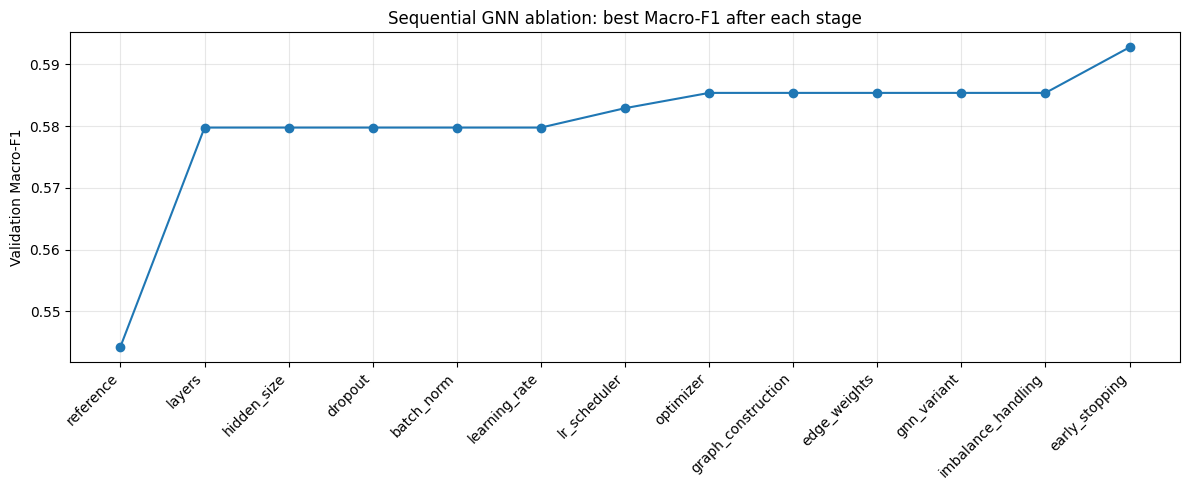

In [19]:

stage_best_rows = []

for stage_name in [
    "reference"
] + [
    stage["stage"]
    for stage in ABLATION_STAGES
]:
    subset = ablation_df[
        ablation_df["ablation_stage"]
        == stage_name
    ]

    if subset.empty:
        continue

    best_idx = subset[
        "val_macro_f1"
    ].idxmax()

    stage_best_rows.append(
        ablation_df.loc[best_idx]
    )

stage_best_df = pd.DataFrame(
    stage_best_rows
).reset_index(drop=True)

display(
    stage_best_df[
        [
            "ablation_stage",
            "candidate_value",
            "variant",
            "val_accuracy",
            "val_macro_f1",
            "val_macro_auc"
        ]
    ]
)

plt.figure(figsize=(12, 5))
plt.plot(
    stage_best_df["ablation_stage"],
    stage_best_df["val_macro_f1"],
    marker="o"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation Macro-F1")
plt.title("Sequential GNN ablation: best Macro-F1 after each stage")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "ablation_stage_best_macro_f1.png",
    dpi=250,
    bbox_inches="tight"
)
plt.show()



# Part E — Final GNN

## 13. Retrain/save the final selected GNN configuration

The final configuration is retrained from scratch with the same fixed train/validation protocol.  
Only after this configuration is fixed do we evaluate on the untouched final test set.


In [20]:

final_result = train_gnn_experiment(
    current_best_config,
    run_name="FINAL_GNN",
    force=True
)

FINAL_GNN_CONFIG = copy.deepcopy(
    final_result["config"]
)

FINAL_GNN_PATH = Path(
    final_result["checkpoint_path"]
)

with open(
    RESULT_DIR / "final_gnn_config.json",
    "w"
) as file:
    json.dump(
        FINAL_GNN_CONFIG,
        file,
        indent=4
    )

print("Final GNN checkpoint:", FINAL_GNN_PATH)
print(
    json.dumps(
        FINAL_GNN_CONFIG,
        indent=4
    )
)


Best-Model-saved
FINAL_GNN | Epoch 01/50 | Train F1 0.1829 | Val F1 0.2695 | Val Acc 0.7051
Best-Model-saved
FINAL_GNN | Epoch 02/50 | Train F1 0.3284 | Val F1 0.3528 | Val Acc 0.7031
Best-Model-saved
FINAL_GNN | Epoch 03/50 | Train F1 0.4123 | Val F1 0.4812 | Val Acc 0.7330
Best-Model-saved
FINAL_GNN | Epoch 04/50 | Train F1 0.5353 | Val F1 0.4975 | Val Acc 0.7523
Best-Model-saved
FINAL_GNN | Epoch 05/50 | Train F1 0.5894 | Val F1 0.5217 | Val Acc 0.7317
Best-Model-saved
FINAL_GNN | Epoch 06/50 | Train F1 0.6287 | Val F1 0.5310 | Val Acc 0.7270
Best-Model-saved
FINAL_GNN | Epoch 07/50 | Train F1 0.6691 | Val F1 0.5582 | Val Acc 0.7497
FINAL_GNN | Epoch 08/50 | Train F1 0.6875 | Val F1 0.5317 | Val Acc 0.7430
FINAL_GNN | Epoch 09/50 | Train F1 0.6972 | Val F1 0.5319 | Val Acc 0.7304
Best-Model-saved
FINAL_GNN | Epoch 10/50 | Train F1 0.7088 | Val F1 0.5688 | Val Acc 0.7557
FINAL_GNN | Epoch 11/50 | Train F1 0.7191 | Val F1 0.5536 | Val Acc 0.7357
FINAL_GNN | Epoch 12/50 | Train F1 0.75

/tmp/ipykernel_58/47617162.py:200: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  checkpoint = torch.load(


Final GNN checkpoint: /kaggle/working/task3_gnn_only/models/FINAL_GNN_2ccda2ae0eaf.pt
{
    "variant": "gatv2",
    "num_layers": 2,
    "hidden_size": 128,
    "dropout": 0.4,
    "batch_norm": true,
    "lr": 0.0002,
    "scheduler": "cosine",
    "optimizer": "adam",
    "graph_method": "grid4",
    "edge_weights": false,
    "imbalance": "weighted_ce",
    "patience": 5,
    "heads": 4
}



## 14. Full test evaluation utilities

Outputs:
- loss / accuracy / Macro-F1 learning curves
- overall accuracy
- balanced accuracy
- precision
- recall
- Macro-F1
- weighted F1
- per-class accuracy
- per-class precision / recall / F1
- confusion matrix
- Macro AUC
- class-wise AUC
- ROC curves
- training time
- testing time
- prediction CSV


In [21]:

def load_trained_gnn(
    checkpoint_path
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE
    )

    config = checkpoint["config"]

    model = FlexibleGNN(
        in_features=NODE_FEATURE_DIM,
        num_classes=NUM_CLASSES,
        variant=config["variant"],
        num_layers=config["num_layers"],
        hidden_size=config["hidden_size"],
        dropout=config["dropout"],
        batch_norm=config["batch_norm"],
        edge_weights=config["edge_weights"],
        heads=config.get("heads", 4)
    ).to(DEVICE)

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    return model, config, checkpoint


@torch.no_grad()
def predict_graph_model(
    model,
    loader
):
    model.eval()

    all_true = []
    all_prob = []
    all_indices = []

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    for batch in loader:
        batch = batch.to(DEVICE)

        logits = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        all_true.extend(
            batch.y.view(-1)
            .cpu()
            .numpy()
        )

        all_prob.extend(
            probabilities
            .cpu()
            .numpy()
        )

        all_indices.extend(
            batch.sample_idx.view(-1)
            .cpu()
            .numpy()
        )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    testing_seconds = (
        time.perf_counter()
        - start
    )

    y_true = np.asarray(all_true)
    y_prob = np.asarray(all_prob)
    sample_idx = np.asarray(all_indices)

    order = np.argsort(sample_idx)

    return {
        "y_true": y_true[order],
        "y_prob": y_prob[order],
        "y_pred": y_prob[order].argmax(axis=1),
        "sample_idx": sample_idx[order],
        "testing_seconds": testing_seconds
    }


def plot_training_history(
    history_path,
    title_prefix
):
    history = pd.read_csv(
        history_path
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 4)
    )

    axes[0].plot(
        history["epoch"],
        history["train_loss"],
        label="Train"
    )
    axes[0].plot(
        history["epoch"],
        history["val_loss"],
        label="Validation"
    )
    axes[0].set_title(
        f"{title_prefix}: Loss"
    )
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(
        history["epoch"],
        history["train_accuracy"],
        label="Train"
    )
    axes[1].plot(
        history["epoch"],
        history["val_accuracy"],
        label="Validation"
    )
    axes[1].set_title(
        f"{title_prefix}: Accuracy"
    )
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    axes[2].plot(
        history["epoch"],
        history["train_macro_f1"],
        label="Train"
    )
    axes[2].plot(
        history["epoch"],
        history["val_macro_f1"],
        label="Validation"
    )
    axes[2].set_title(
        f"{title_prefix}: Macro-F1"
    )
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(
        PLOT_DIR
        / f"{title_prefix.lower().replace(' ', '_')}_learning_curves.png",
        dpi=250,
        bbox_inches="tight"
    )
    plt.show()


def full_test_report(
    model_name,
    prediction,
    training_seconds
):
    y_true = prediction["y_true"]
    y_pred = prediction["y_pred"]
    y_prob = prediction["y_prob"]

    metrics = calculate_metrics(
        y_true,
        y_pred,
        y_prob
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES)
    )

    per_class_precision = precision_score(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        average=None,
        zero_division=0
    )

    per_class_recall = recall_score(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        average=None,
        zero_division=0
    )

    per_class_f1 = f1_score(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        average=None,
        zero_division=0
    )

    per_class_accuracy = np.divide(
        np.diag(cm),
        cm.sum(axis=1),
        out=np.zeros(
            NUM_CLASSES,
            dtype=float
        ),
        where=cm.sum(axis=1) != 0
    )

    y_binary = label_binarize(
        y_true,
        classes=np.arange(NUM_CLASSES)
    )

    per_class_auc = []

    for class_index in range(NUM_CLASSES):
        try:
            auc_value = roc_auc_score(
                y_binary[:, class_index],
                y_prob[:, class_index]
            )
        except ValueError:
            auc_value = np.nan

        per_class_auc.append(
            auc_value
        )

    per_class_df = pd.DataFrame({
        "class": CLASS_NAMES,
        "accuracy": per_class_accuracy,
        "precision": per_class_precision,
        "recall": per_class_recall,
        "f1": per_class_f1,
        "auc_ovr": per_class_auc,
        "support": cm.sum(axis=1)
    })

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    print(
        f"Accuracy:          {metrics['accuracy']:.4f}"
    )
    print(
        f"Balanced Accuracy: {metrics['balanced_accuracy']:.4f}"
    )
    print(
        f"Macro Precision:   {metrics['macro_precision']:.4f}"
    )
    print(
        f"Macro Recall:      {metrics['macro_recall']:.4f}"
    )
    print(
        f"Macro F1:          {metrics['macro_f1']:.4f}"
    )
    print(
        f"Macro AUC:         {metrics['macro_auc']:.4f}"
    )
    print(
        f"Training Time:     {training_seconds:.2f} s"
    )
    print(
        f"Testing Time:      {prediction['testing_seconds']:.2f} s"
    )

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=np.arange(NUM_CLASSES),
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0
        )
    )

    display(
        per_class_df.round(4)
    )

    # Confusion matrix
    fig, ax = plt.subplots(
        figsize=(8, 7)
    )

    image = ax.imshow(cm)

    ax.set_title(
        f"{model_name} Confusion Matrix"
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax.set_xticks(
        np.arange(NUM_CLASSES)
    )
    ax.set_yticks(
        np.arange(NUM_CLASSES)
    )

    ax.set_xticklabels(
        CLASS_NAMES,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        CLASS_NAMES
    )

    threshold = cm.max() / 2

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color=(
                    "white"
                    if cm[i, j] > threshold
                    else "black"
                )
            )

    fig.colorbar(
        image,
        ax=ax
    )

    plt.tight_layout()

    plt.savefig(
        PLOT_DIR
        / f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png",
        dpi=250,
        bbox_inches="tight"
    )

    plt.show()

    # ROC curves
    plt.figure(
        figsize=(9, 7)
    )

    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):
        try:
            fpr, tpr, _ = roc_curve(
                y_binary[:, class_index],
                y_prob[:, class_index]
            )

            class_auc = auc(
                fpr,
                tpr
            )

            plt.plot(
                fpr,
                tpr,
                label=(
                    f"{class_name} "
                    f"(AUC={class_auc:.3f})"
                )
            )

        except ValueError:
            pass

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Chance"
    )

    plt.xlabel(
        "False Positive Rate"
    )
    plt.ylabel(
        "True Positive Rate"
    )
    plt.title(
        f"{model_name} One-vs-Rest ROC"
    )
    plt.legend(
        loc="lower right"
    )
    plt.tight_layout()

    plt.savefig(
        PLOT_DIR
        / f"{model_name.lower().replace(' ', '_')}_roc.png",
        dpi=250,
        bbox_inches="tight"
    )

    plt.show()

    summary = {
        "model": model_name,
        **metrics,
        "training_seconds": float(
            training_seconds
        ),
        "testing_seconds": float(
            prediction["testing_seconds"]
        )
    }

    return summary, per_class_df, cm



## 15. Evaluate the first/reference GNN and final improved GNN on the same untouched test set


/tmp/ipykernel_58/3245277062.py:4: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  checkpoint = torch.load(



Initial GATv2
Accuracy:          0.7337
Balanced Accuracy: 0.6023
Macro Precision:   0.4926
Macro Recall:      0.6023
Macro F1:          0.5358
Macro AUC:         0.8661
Training Time:     87.30 s
Testing Time:      0.32 s

Classification report:
              precision    recall  f1-score   support

       akiec     0.2903    0.3600    0.3214        50
         bcc     0.4299    0.6053    0.5027        76
         bkl     0.4975    0.6037    0.5455       164
          df     0.3462    0.6000    0.4390        15
         mel     0.4900    0.5868    0.5341       167
          nv     0.9299    0.8107    0.8662      1014
        vasc     0.4643    0.6500    0.5417        20

    accuracy                         0.7337      1506
   macro avg     0.4926    0.6023    0.5358      1506
weighted avg     0.7755    0.7337    0.7494      1506



,class,accuracy,precision,recall,f1,auc_ovr,support
0,akiec,0.3600,0.2903,0.3600,0.3214,0.7837,50
1,bcc,0.6053,0.4299,0.6053,0.5027,0.8796,76
2,bkl,0.6037,0.4975,0.6037,0.5455,0.8856,164
3,df,0.6000,0.3462,0.6000,0.4390,0.8333,15
4,mel,0.5868,0.4900,0.5868,0.5341,0.8676,167
5,nv,0.8107,0.9299,0.8107,0.8662,0.9252,1014
6,vasc,0.6500,0.4643,0.6500,0.5417,0.8880,20


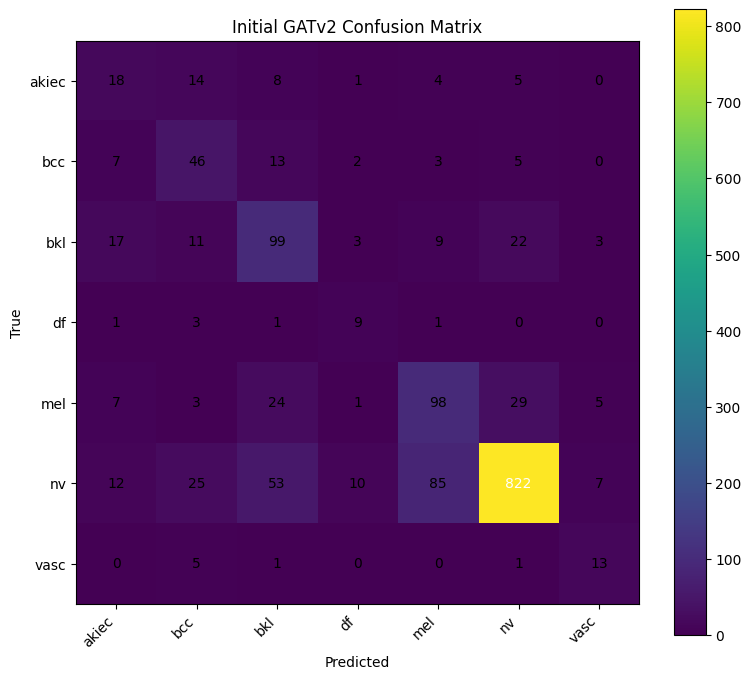

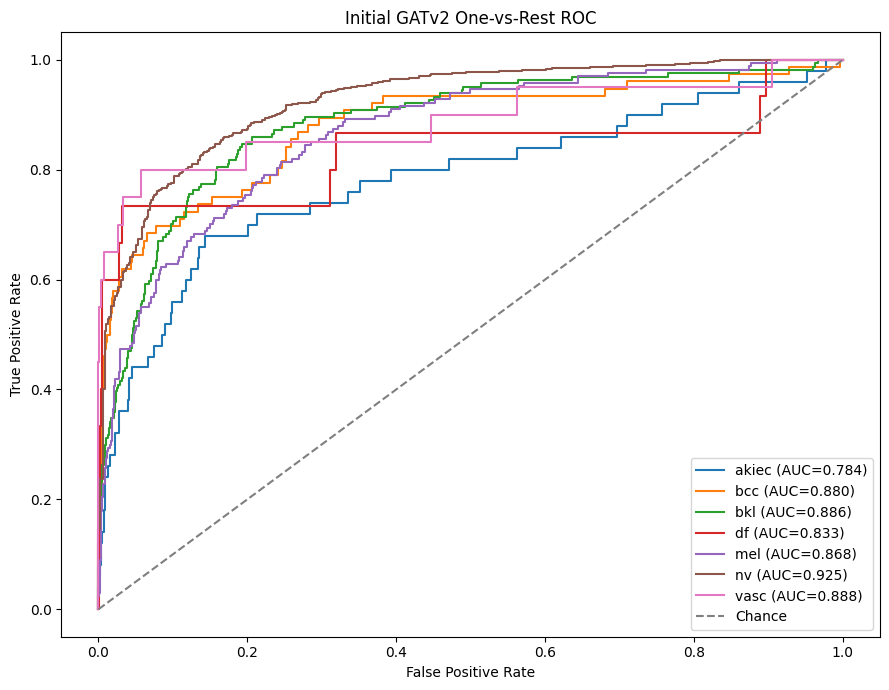

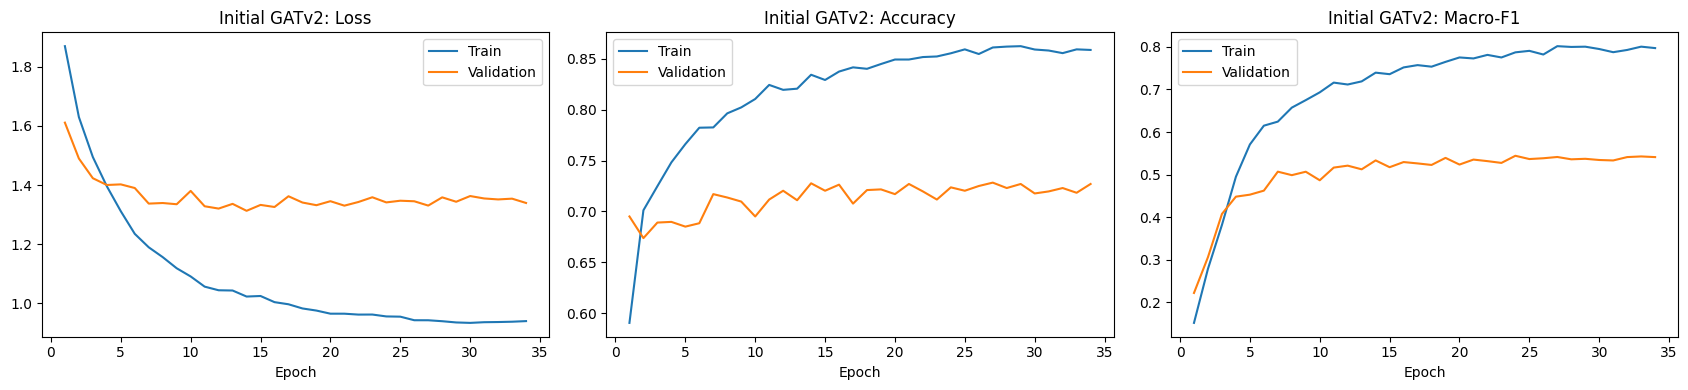

/tmp/ipykernel_58/3245277062.py:4: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  checkpoint = torch.load(



Final GNN
Accuracy:          0.7543
Balanced Accuracy: 0.5668
Macro Precision:   0.5347
Macro Recall:      0.5668
Macro F1:          0.5453
Macro AUC:         0.8806
Training Time:     40.82 s
Testing Time:      0.27 s

Classification report:
              precision    recall  f1-score   support

       akiec     0.3810    0.3200    0.3478        50
         bcc     0.4688    0.5921    0.5233        76
         bkl     0.5414    0.5976    0.5681       164
          df     0.3043    0.4667    0.3684        15
         mel     0.4901    0.5928    0.5366       167
          nv     0.9101    0.8481    0.8780      1014
        vasc     0.6471    0.5500    0.5946        20

    accuracy                         0.7543      1506
   macro avg     0.5347    0.5668    0.5453      1506
weighted avg     0.7740    0.7543    0.7621      1506



,class,accuracy,precision,recall,f1,auc_ovr,support
0,akiec,0.3200,0.3810,0.3200,0.3478,0.8098,50
1,bcc,0.5921,0.4688,0.5921,0.5233,0.9027,76
2,bkl,0.5976,0.5414,0.5976,0.5681,0.8860,164
3,df,0.4667,0.3043,0.4667,0.3684,0.8598,15
4,mel,0.5928,0.4901,0.5928,0.5366,0.8808,167
5,nv,0.8481,0.9101,0.8481,0.8780,0.9284,1014
6,vasc,0.5500,0.6471,0.5500,0.5946,0.8963,20


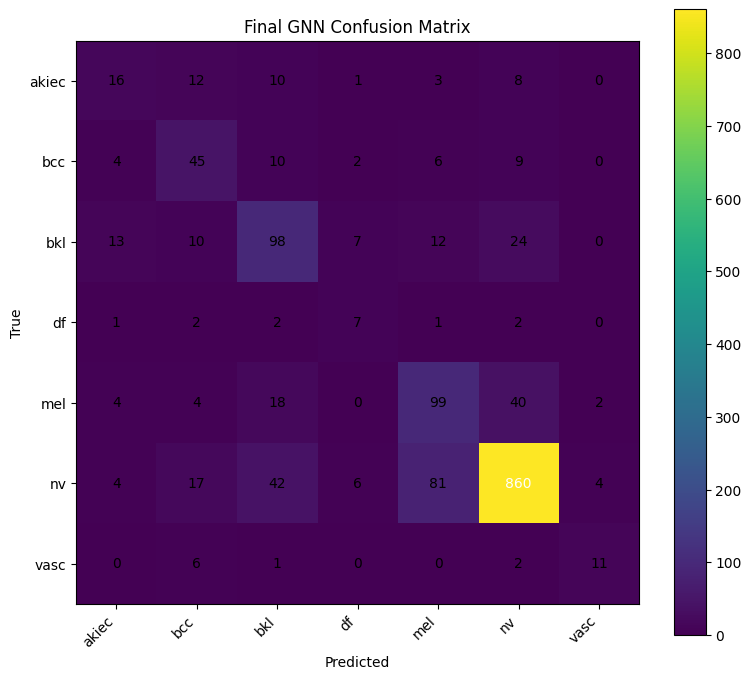

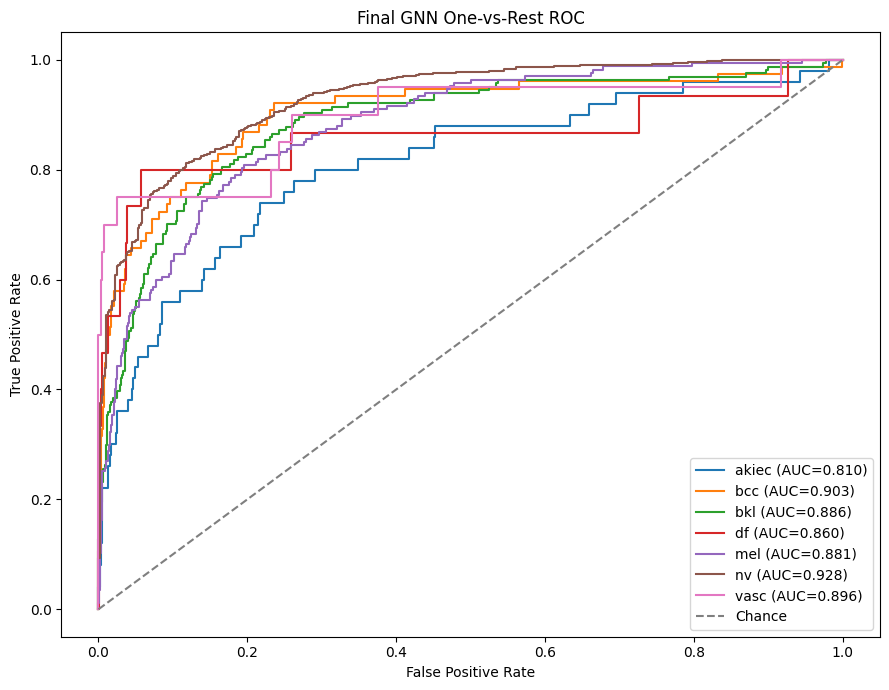

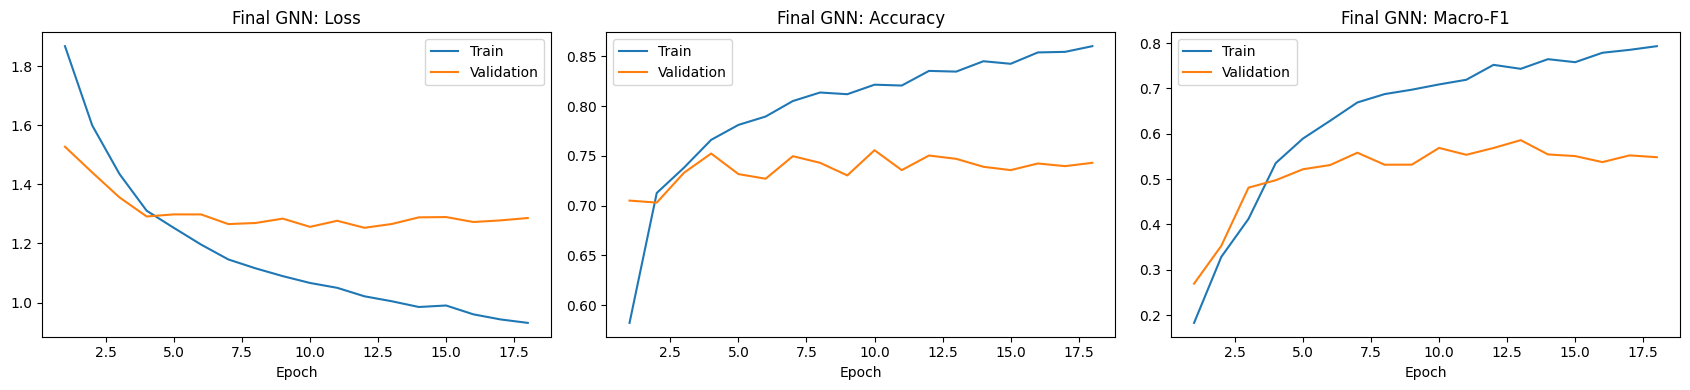

In [22]:

# ------------------------------------------------------------
# Initial/reference GNN test evaluation
# ------------------------------------------------------------
initial_model, initial_config_loaded, _ = load_trained_gnn(
    initial_result["checkpoint_path"]
)

initial_test_loader = get_graph_loaders(
    initial_config_loaded["graph_method"]
)["test"]

initial_prediction = predict_graph_model(
    initial_model,
    initial_test_loader
)

initial_summary, initial_per_class, initial_cm = full_test_report(
    "Initial GATv2",
    initial_prediction,
    initial_result["summary"]["training_seconds"]
)

plot_training_history(
    initial_result["history_path"],
    "Initial GATv2"
)

# ------------------------------------------------------------
# Final GNN test evaluation
# ------------------------------------------------------------
final_model, final_config_loaded, _ = load_trained_gnn(
    final_result["checkpoint_path"]
)

final_test_loader = get_graph_loaders(
    final_config_loaded["graph_method"]
)["test"]

final_prediction = predict_graph_model(
    final_model,
    final_test_loader
)

final_summary, final_per_class, final_cm = full_test_report(
    "Final GNN",
    final_prediction,
    final_result["summary"]["training_seconds"]
)

plot_training_history(
    final_result["history_path"],
    "Final GNN"
)


In [29]:

# Save aligned per-image predictions.
final_prediction_df = test_df.copy().reset_index(drop=True)

if len(final_prediction_df) != len(final_prediction["y_true"]):
    raise ValueError(
        "Final-test prediction count does not match final_test_split."
    )

final_prediction_df["true_label"] = final_prediction["y_true"]
final_prediction_df["predicted_label"] = final_prediction["y_pred"]

final_prediction_df["true_class"] = [
    IDX_TO_CLASS[int(x)]
    for x in final_prediction["y_true"]
]

final_prediction_df["predicted_class"] = [
    IDX_TO_CLASS[int(x)]
    for x in final_prediction["y_pred"]
]

final_prediction_df["correct"] = (
    final_prediction_df["true_label"]
    == final_prediction_df["predicted_label"]
)

final_prediction_df["confidence"] = (
    final_prediction["y_prob"].max(axis=1)
)

for class_index, class_name in enumerate(CLASS_NAMES):
    final_prediction_df[
        f"probability_{class_name}"
    ] = final_prediction["y_prob"][
        :,
        class_index
    ]

final_prediction_df.to_csv(
    RESULT_DIR / "final_gnn_test_predictions.csv",
    index=False
)

initial_prediction_df = test_df.copy().reset_index(drop=True)
initial_prediction_df["true_label"] = initial_prediction["y_true"]
initial_prediction_df["predicted_label"] = initial_prediction["y_pred"]
initial_prediction_df["correct"] = (
    initial_prediction["y_true"]
    == initial_prediction["y_pred"]
)

initial_prediction_df.to_csv(
    RESULT_DIR / "initial_gatv2_test_predictions.csv",
    index=False
)

print("Prediction CSV files saved.")


Prediction CSV files saved.



# Part F — Time-saving uncertainty estimate instead of 5-fold

## 16. Lesion-level bootstrap 95% confidence intervals

Because images from the same lesion are not independent, the bootstrap resamples **lesion IDs**, not individual images.

No model retraining is required.


In [26]:

# ============================================================
# CELL 16 - FIXED
# LESION-LEVEL BOOTSTRAP 95% CONFIDENCE INTERVAL
# ============================================================

# ------------------------------------------------------------
# STEP 1: Check required previous outputs
# ------------------------------------------------------------

if "final_prediction" not in globals():
    raise RuntimeError(
        "final_prediction is not available.\n"
        "Please run the Final GNN test prediction cell first."
    )

if "test_df" not in globals():
    raise RuntimeError(
        "test_df is not available.\n"
        "Please run the dataset split cells first."
    )


# ------------------------------------------------------------
# STEP 2: Extract Final GNN predictions
# ------------------------------------------------------------

y_true_final = np.asarray(
    final_prediction["y_true"]
)

y_pred_final = np.asarray(
    final_prediction["y_pred"]
)

y_prob_final = np.asarray(
    final_prediction["y_prob"]
)


# ------------------------------------------------------------
# STEP 3: Create final_prediction_df safely
# ------------------------------------------------------------

if len(test_df) != len(y_true_final):
    raise ValueError(
        f"Prediction count mismatch!\n"
        f"test_df images = {len(test_df)}\n"
        f"predictions    = {len(y_true_final)}"
    )


final_prediction_df = (
    test_df
    .copy()
    .reset_index(drop=True)
)


final_prediction_df["true_label"] = (
    y_true_final.astype(int)
)

final_prediction_df["predicted_label"] = (
    y_pred_final.astype(int)
)


# Class names
final_prediction_df["true_class"] = [
    IDX_TO_CLASS[int(label)]
    for label in y_true_final
]

final_prediction_df["predicted_class"] = [
    IDX_TO_CLASS[int(label)]
    for label in y_pred_final
]


# Correct / incorrect prediction
final_prediction_df["correct"] = (
    final_prediction_df["true_label"]
    ==
    final_prediction_df["predicted_label"]
)


# Prediction confidence
final_prediction_df["confidence"] = (
    y_prob_final.max(axis=1)
)


# Save probability for every class
for class_index, class_name in enumerate(CLASS_NAMES):

    final_prediction_df[
        f"probability_{class_name}"
    ] = y_prob_final[:, class_index]


print("final_prediction_df created successfully.")

print(
    "Number of final test predictions:",
    len(final_prediction_df)
)

print(
    "Number of unique lesions:",
    final_prediction_df["lesion_id"].nunique()
)

display(
    final_prediction_df[
        [
            "image_id",
            "lesion_id",
            "true_class",
            "predicted_class",
            "correct",
            "confidence"
        ]
    ].head()
)


# ============================================================
# STEP 4: LESION-LEVEL BOOTSTRAP FUNCTION
# ============================================================

def lesion_level_bootstrap(
    prediction_df,
    y_prob,
    n_bootstrap=1000,
    seed=42
):

    rng = np.random.default_rng(seed)

    # ------------------------------------------
    # Unique lesions
    # ------------------------------------------

    lesion_ids = (
        prediction_df["lesion_id"]
        .astype(str)
        .values
    )

    unique_lesions = np.unique(
        lesion_ids
    )


    # ------------------------------------------
    # Map each lesion → corresponding image rows
    # ------------------------------------------

    lesion_to_indices = {
        lesion_id: np.where(
            lesion_ids == lesion_id
        )[0]

        for lesion_id in unique_lesions
    }


    bootstrap_records = []


    # ========================================================
    # BOOTSTRAP
    # ========================================================

    for iteration in range(
        n_bootstrap
    ):

        # --------------------------------------
        # Sample LESIONS with replacement
        # --------------------------------------

        sampled_lesions = rng.choice(
            unique_lesions,
            size=len(unique_lesions),
            replace=True
        )


        # --------------------------------------
        # Get all images belonging to those lesions
        # --------------------------------------

        sampled_indices = np.concatenate([
            lesion_to_indices[lesion_id]

            for lesion_id
            in sampled_lesions
        ])


        # --------------------------------------
        # Bootstrap true labels
        # --------------------------------------

        y_true_boot = (
            prediction_df[
                "true_label"
            ]
            .values[
                sampled_indices
            ]
        )


        # --------------------------------------
        # Bootstrap predictions
        # --------------------------------------

        y_pred_boot = (
            prediction_df[
                "predicted_label"
            ]
            .values[
                sampled_indices
            ]
        )


        # --------------------------------------
        # Bootstrap probabilities
        # --------------------------------------

        y_prob_boot = (
            y_prob[
                sampled_indices
            ]
        )


        # ====================================================
        # METRICS
        # ====================================================

        accuracy = accuracy_score(
            y_true_boot,
            y_pred_boot
        )


        balanced_acc = balanced_accuracy_score(
            y_true_boot,
            y_pred_boot
        )


        macro_precision = precision_score(
            y_true_boot,
            y_pred_boot,
            average="macro",
            zero_division=0
        )


        macro_recall = recall_score(
            y_true_boot,
            y_pred_boot,
            average="macro",
            zero_division=0
        )


        macro_f1 = f1_score(
            y_true_boot,
            y_pred_boot,
            average="macro",
            zero_division=0
        )


        weighted_f1 = f1_score(
            y_true_boot,
            y_pred_boot,
            average="weighted",
            zero_division=0
        )


        # --------------------------------------
        # Macro AUC
        # Some bootstrap samples may miss a
        # minority class, so handle safely.
        # --------------------------------------

        try:

            macro_auc = roc_auc_score(
                y_true_boot,
                y_prob_boot,
                labels=np.arange(NUM_CLASSES),
                multi_class="ovr",
                average="macro"
            )

        except ValueError:

            macro_auc = np.nan


        bootstrap_records.append({

            "accuracy":
                accuracy,

            "balanced_accuracy":
                balanced_acc,

            "macro_precision":
                macro_precision,

            "macro_recall":
                macro_recall,

            "macro_f1":
                macro_f1,

            "weighted_f1":
                weighted_f1,

            "macro_auc":
                macro_auc
        })


    # ========================================================
    # Convert all bootstrap results to DataFrame
    # ========================================================

    bootstrap_df = pd.DataFrame(
        bootstrap_records
    )


    # ========================================================
    # 95% CONFIDENCE INTERVAL
    # ========================================================

    summary_records = []


    metric_names = [

        "accuracy",

        "balanced_accuracy",

        "macro_precision",

        "macro_recall",

        "macro_f1",

        "weighted_f1",

        "macro_auc"
    ]


    for metric_name in metric_names:

        values = (
            bootstrap_df[
                metric_name
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
            .dropna()
        )


        if len(values) == 0:

            summary_records.append({

                "metric":
                    metric_name,

                "original_value":
                    np.nan,

                "bootstrap_mean":
                    np.nan,

                "bootstrap_std":
                    np.nan,

                "ci_2.5%":
                    np.nan,

                "ci_97.5%":
                    np.nan
            })

            continue


        # --------------------------------------
        # Original Final-GNN metric
        # --------------------------------------

        if metric_name == "accuracy":

            original_value = accuracy_score(
                prediction_df["true_label"],
                prediction_df["predicted_label"]
            )


        elif metric_name == "balanced_accuracy":

            original_value = balanced_accuracy_score(
                prediction_df["true_label"],
                prediction_df["predicted_label"]
            )


        elif metric_name == "macro_precision":

            original_value = precision_score(
                prediction_df["true_label"],
                prediction_df["predicted_label"],
                average="macro",
                zero_division=0
            )


        elif metric_name == "macro_recall":

            original_value = recall_score(
                prediction_df["true_label"],
                prediction_df["predicted_label"],
                average="macro",
                zero_division=0
            )


        elif metric_name == "macro_f1":

            original_value = f1_score(
                prediction_df["true_label"],
                prediction_df["predicted_label"],
                average="macro",
                zero_division=0
            )


        elif metric_name == "weighted_f1":

            original_value = f1_score(
                prediction_df["true_label"],
                prediction_df["predicted_label"],
                average="weighted",
                zero_division=0
            )


        elif metric_name == "macro_auc":

            try:

                original_value = roc_auc_score(
                    prediction_df["true_label"],
                    y_prob,
                    labels=np.arange(NUM_CLASSES),
                    multi_class="ovr",
                    average="macro"
                )

            except ValueError:

                original_value = np.nan


        summary_records.append({

            "metric":
                metric_name,

            "original_value":
                original_value,

            "bootstrap_mean":
                values.mean(),

            "bootstrap_std":
                values.std(ddof=1),

            "ci_2.5%":
                values.quantile(0.025),

            "ci_97.5%":
                values.quantile(0.975)
        })


    bootstrap_summary = pd.DataFrame(
        summary_records
    )


    return (
        bootstrap_df,
        bootstrap_summary
    )


# ============================================================
# STEP 5: RUN 1000 LESION-LEVEL BOOTSTRAP ITERATIONS
# ============================================================

print("\n" + "=" * 70)
print("Starting lesion-level bootstrap...")
print("=" * 70)


bootstrap_raw_df, bootstrap_summary_df = (
    lesion_level_bootstrap(

        prediction_df=
            final_prediction_df,

        y_prob=
            y_prob_final,

        n_bootstrap=
            1000,

        seed=
            SEED
    )
)


# ============================================================
# STEP 6: SAVE RESULTS
# ============================================================

bootstrap_raw_df.to_csv(
    RESULT_DIR
    / "final_gnn_bootstrap_raw.csv",
    index=False
)


bootstrap_summary_df.to_csv(
    RESULT_DIR
    / "final_gnn_bootstrap_95ci.csv",
    index=False
)


final_prediction_df.to_csv(
    RESULT_DIR
    / "final_gnn_test_predictions.csv",
    index=False
)


# ============================================================
# STEP 7: DISPLAY FINAL RESULT
# ============================================================

print("\n" + "=" * 85)
print("FINAL GNN — LESION-LEVEL BOOTSTRAP 95% CONFIDENCE INTERVAL")
print("=" * 85)


display(
    bootstrap_summary_df.round(4)
)


print("\nBootstrap completed successfully.")

print(
    "\nResults saved to:",
    RESULT_DIR
)


final_prediction_df created successfully.
Number of final test predictions: 1506
Number of unique lesions: 1121


,image_id,lesion_id,true_class,predicted_class,correct,confidence
0,ISIC_0027828,HAM_0002521,bkl,nv,False,0.386733
1,ISIC_0029291,HAM_0002521,bkl,mel,False,0.400809
2,ISIC_0030698,HAM_0006574,bkl,nv,False,0.503588
3,ISIC_0025567,HAM_0006574,bkl,bkl,True,0.800121
4,ISIC_0031159,HAM_0005772,bkl,bkl,True,0.818030



Starting lesion-level bootstrap...

FINAL GNN — LESION-LEVEL BOOTSTRAP 95% CONFIDENCE INTERVAL


,metric,original_value,bootstrap_mean,bootstrap_std,ci_2.5%,ci_97.5%
0,accuracy,0.7543,0.7547,0.0127,0.7293,0.7790
1,balanced_accuracy,0.5668,0.5702,0.0344,0.5043,0.6409
2,macro_precision,0.5347,0.5362,0.0296,0.4768,0.5897
3,macro_recall,0.5668,0.5702,0.0344,0.5043,0.6409
4,macro_f1,0.5453,0.5434,0.0283,0.4846,0.5966
5,weighted_f1,0.7621,0.7623,0.0125,0.7374,0.7858
6,macro_auc,0.8806,0.8817,0.0182,0.8440,0.9124



Bootstrap completed successfully.

Results saved to: /kaggle/working/task3_gnn_only/results



# Part G — Compare with the four uploaded baseline notebooks

## 17. Baseline results are reference-only

The numbers below come from the uploaded notebooks.  
They are **not retrained or modified** here.

### Uploaded baseline notebook results used

- **ResNet50:** test accuracy ≈ 0.7851, Macro-F1 ≈ 0.5887; 1494-image lesion-level holdout.
- **EfficientNet-B2:** test accuracy ≈ 0.8052, Macro-F1 ≈ 0.6152; 1494-image lesion-level holdout.
- **ViT-B/16 five-model probability ensemble:** final-test accuracy ≈ 0.8652, Macro-F1 ≈ 0.7777; 1506-image lesion-level final test.
- **Swin-Tiny five-model probability ensemble:** final-test accuracy ≈ 0.8546, Macro-F1 ≈ 0.7289, Macro ROC-AUC ≈ 0.9729; 1506-image lesion-level final test.

The GNN uses the same seed-171 15% final-test split as ViT-B/16 and Swin-Tiny.

**Important:** ViT and Swin numbers are five-model ensembles, while the Final GNN here is a single GNN model. The comparison table states this explicitly.


In [30]:

BASELINE_RESULTS = pd.DataFrame([
    {
        "model": "ResNet50",
        "model_type": "single baseline",
        "accuracy": 0.7851,
        "macro_precision": 0.5672,
        "macro_recall": 0.6918,
        "macro_f1": 0.5887,
        "weighted_f1": 0.7805,
        "macro_auc": np.nan,
        "test_images": 1494,
        "test_protocol": "lesion-level 70/15/15 holdout",
        "same_final_test_as_gnn": False
    },
    {
        "model": "EfficientNet-B2",
        "model_type": "single baseline",
        "accuracy": 0.8052,
        "macro_precision": 0.5956,
        "macro_recall": 0.6638,
        "macro_f1": 0.6152,
        "weighted_f1": 0.8050,
        "macro_auc": np.nan,
        "test_images": 1494,
        "test_protocol": "lesion-level 70/15/15 holdout",
        "same_final_test_as_gnn": False
    },
    {
        "model": "ViT-B/16",
        "model_type": "5-model probability ensemble",
        "accuracy": 0.865206,
        "macro_precision": 0.777153,
        "macro_recall": 0.785932,
        "macro_f1": 0.777735,
        "weighted_f1": 0.867676,
        # Mean of the seven class-wise OvR AUCs shown in the uploaded notebook.
        "macro_auc": 0.977190,
        "test_images": 1506,
        "test_protocol": "seed-171 lesion-level 15% final test",
        "same_final_test_as_gnn": True
    },
    {
        "model": "Swin-Tiny",
        "model_type": "5-model probability ensemble",
        "accuracy": 0.854582,
        "macro_precision": 0.763154,
        "macro_recall": 0.739497,
        "macro_f1": 0.728886,
        "weighted_f1": 0.858057,
        "macro_auc": 0.972863,
        "test_images": 1506,
        "test_protocol": "seed-171 lesion-level 15% final test",
        "same_final_test_as_gnn": True
    }
])


gnn_rows = pd.DataFrame([
    {
        "model": "Initial GATv2",
        "model_type": "single GNN",
        "accuracy": initial_summary["accuracy"],
        "macro_precision": initial_summary["macro_precision"],
        "macro_recall": initial_summary["macro_recall"],
        "macro_f1": initial_summary["macro_f1"],
        "weighted_f1": initial_summary["weighted_f1"],
        "macro_auc": initial_summary["macro_auc"],
        "test_images": len(test_df),
        "test_protocol": "seed-171 lesion-level 15% final test",
        "same_final_test_as_gnn": True
    },
    {
        "model": "Final GNN",
        "model_type": "single improved GNN",
        "accuracy": final_summary["accuracy"],
        "macro_precision": final_summary["macro_precision"],
        "macro_recall": final_summary["macro_recall"],
        "macro_f1": final_summary["macro_f1"],
        "weighted_f1": final_summary["weighted_f1"],
        "macro_auc": final_summary["macro_auc"],
        "test_images": len(test_df),
        "test_protocol": "seed-171 lesion-level 15% final test",
        "same_final_test_as_gnn": True
    }
])


comparison_df = pd.concat(
    [
        BASELINE_RESULTS,
        gnn_rows
    ],
    ignore_index=True
)

comparison_df.to_csv(
    RESULT_DIR / "baseline_and_gnn_comparison.csv",
    index=False
)

display(
    comparison_df.sort_values(
        "macro_f1",
        ascending=False
    ).reset_index(drop=True).round(4)
)


,model,model_type,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_auc,test_images,test_protocol,same_final_test_as_gnn
0,ViT-B/16,5-model probability ensemble,0.8652,0.7772,0.7859,0.7777,0.8677,0.9772,1506,seed-171 lesion-level 15% final test,True
1,Swin-Tiny,5-model probability ensemble,0.8546,0.7632,0.7395,0.7289,0.8581,0.9729,1506,seed-171 lesion-level 15% final test,True
2,EfficientNet-B2,single baseline,0.8052,0.5956,0.6638,0.6152,0.8050,NaN,1494,lesion-level 70/15/15 holdout,False
3,ResNet50,single baseline,0.7851,0.5672,0.6918,0.5887,0.7805,NaN,1494,lesion-level 70/15/15 holdout,False
4,Final GNN,single improved GNN,0.7543,0.5347,0.5668,0.5453,0.7621,0.8806,1506,seed-171 lesion-level 15% final test,True
5,Initial GATv2,single GNN,0.7337,0.4926,0.6023,0.5358,0.7494,0.8661,1506,seed-171 lesion-level 15% final test,True



# Part H — Statistical significance vs best baseline

## 18. Best baseline selection

The best uploaded baseline is selected by **Macro-F1**.

### Preferred test: paired McNemar
If the ViT/Swin baseline prediction CSV is available in `/kaggle/input` or `/kaggle/working`, the notebook:
1. aligns images by `image_id`,
2. verifies the true labels,
3. performs an exact paired McNemar/binomial test.

### Fallback
If the baseline prediction CSV is not available, exact pairing cannot be reconstructed from notebook summary numbers alone.  
The notebook then runs an **aggregate two-proportion z-test** and clearly labels it as a weaker, unpaired fallback.

For the final report, prefer the paired McNemar result whenever possible.


In [31]:

best_baseline_row = (
    BASELINE_RESULTS
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .iloc[0]
)

BEST_BASELINE_NAME = str(
    best_baseline_row["model"]
)

print(
    "Best uploaded baseline by Macro-F1:",
    BEST_BASELINE_NAME
)

print(
    "Baseline Macro-F1:",
    f"{best_baseline_row['macro_f1']:.4f}"
)

print(
    "Baseline accuracy:",
    f"{best_baseline_row['accuracy']:.4f}"
)


Best uploaded baseline by Macro-F1: ViT-B/16
Baseline Macro-F1: 0.7777
Baseline accuracy: 0.8652


In [32]:

def find_best_baseline_prediction_csv(
    baseline_name
):
    search_roots = [
        Path("/kaggle/input"),
        Path("/kaggle/working")
    ]

    candidates = []

    for root in search_roots:
        if not root.exists():
            continue

        if baseline_name == "ViT-B/16":
            patterns = [
                "*vit*ensemble_test_predictions.csv",
                "*ensemble_test_predictions.csv"
            ]
        elif baseline_name == "Swin-Tiny":
            patterns = [
                "*swin*ensemble_final_test_predictions.csv",
                "*swin*ensemble_test_predictions.csv",
                "*ensemble_final_test_predictions.csv"
            ]
        else:
            patterns = [
                "*test_predictions.csv"
            ]

        for pattern in patterns:
            candidates.extend(
                root.rglob(pattern)
            )

    # Prefer a path containing the model keyword.
    model_keyword = (
        "vit"
        if baseline_name == "ViT-B/16"
        else "swin"
        if baseline_name == "Swin-Tiny"
        else baseline_name.lower()
    )

    preferred = [
        path
        for path in candidates
        if model_keyword in str(path).lower()
    ]

    if preferred:
        return preferred[0]

    if candidates:
        return candidates[0]

    return None


def paired_mcnemar_from_prediction_csv(
    final_gnn_predictions,
    baseline_csv_path
):
    baseline_predictions = pd.read_csv(
        baseline_csv_path
    )

    required_columns = {
        "image_id",
        "true_label",
        "predicted_label"
    }

    if not required_columns.issubset(
        baseline_predictions.columns
    ):
        raise ValueError(
            "Baseline prediction CSV must contain "
            "image_id, true_label, predicted_label."
        )

    gnn_subset = final_gnn_predictions[
        [
            "image_id",
            "true_label",
            "predicted_label"
        ]
    ].copy()

    gnn_subset = gnn_subset.rename(
        columns={
            "predicted_label": "gnn_predicted_label",
            "true_label": "gnn_true_label"
        }
    )

    baseline_subset = baseline_predictions[
        [
            "image_id",
            "true_label",
            "predicted_label"
        ]
    ].copy()

    baseline_subset = baseline_subset.rename(
        columns={
            "predicted_label": "baseline_predicted_label",
            "true_label": "baseline_true_label"
        }
    )

    merged = gnn_subset.merge(
        baseline_subset,
        on="image_id",
        how="inner"
    )

    if len(merged) != len(final_gnn_predictions):
        raise ValueError(
            "Baseline predictions do not contain exactly "
            "the same final-test image IDs as the GNN."
        )

    if not np.array_equal(
        merged["gnn_true_label"].values,
        merged["baseline_true_label"].values
    ):
        raise ValueError(
            "True labels do not match after image_id alignment."
        )

    true_labels = merged[
        "gnn_true_label"
    ].values

    gnn_correct = (
        merged["gnn_predicted_label"].values
        == true_labels
    )

    baseline_correct = (
        merged["baseline_predicted_label"].values
        == true_labels
    )

    baseline_only_correct = int(
        np.sum(
            baseline_correct
            & ~gnn_correct
        )
    )

    gnn_only_correct = int(
        np.sum(
            gnn_correct
            & ~baseline_correct
        )
    )

    discordant = (
        baseline_only_correct
        + gnn_only_correct
    )

    if discordant == 0:
        p_value = 1.0
    else:
        p_value = binomtest(
            k=min(
                baseline_only_correct,
                gnn_only_correct
            ),
            n=discordant,
            p=0.5,
            alternative="two-sided"
        ).pvalue

    return {
        "test": "Exact paired McNemar/binomial",
        "paired": True,
        "n_aligned": int(len(merged)),
        "baseline_only_correct": baseline_only_correct,
        "gnn_only_correct": gnn_only_correct,
        "p_value": float(p_value),
        "significant_at_0.05": bool(
            p_value < 0.05
        )
    }


def two_proportion_accuracy_test(
    gnn_accuracy,
    gnn_n,
    baseline_accuracy,
    baseline_n
):
    gnn_correct = int(
        round(
            gnn_accuracy * gnn_n
        )
    )

    baseline_correct = int(
        round(
            baseline_accuracy * baseline_n
        )
    )

    pooled = (
        gnn_correct
        + baseline_correct
    ) / (
        gnn_n
        + baseline_n
    )

    standard_error = math.sqrt(
        pooled
        * (1 - pooled)
        * (
            1 / gnn_n
            + 1 / baseline_n
        )
    )

    if standard_error == 0:
        z_value = 0.0
        p_value = 1.0
    else:
        z_value = (
            gnn_accuracy
            - baseline_accuracy
        ) / standard_error

        p_value = (
            2
            * (
                1
                - norm.cdf(
                    abs(z_value)
                )
            )
        )

    return {
        "test": "Two-proportion z-test (aggregate fallback)",
        "paired": False,
        "z_value": float(z_value),
        "p_value": float(p_value),
        "significant_at_0.05": bool(
            p_value < 0.05
        ),
        "warning": (
            "This fallback is weaker than paired McNemar because "
            "baseline per-image predictions were not available."
        )
    }


baseline_prediction_csv = find_best_baseline_prediction_csv(
    BEST_BASELINE_NAME
)

if baseline_prediction_csv is not None:
    print(
        "Baseline prediction CSV found:",
        baseline_prediction_csv
    )

    significance_result = (
        paired_mcnemar_from_prediction_csv(
            final_prediction_df,
            baseline_prediction_csv
        )
    )

else:
    print(
        "No per-image prediction CSV was found for",
        BEST_BASELINE_NAME
    )

    print(
        "Using aggregate two-proportion fallback."
    )

    significance_result = (
        two_proportion_accuracy_test(
            gnn_accuracy=final_summary[
                "accuracy"
            ],
            gnn_n=len(test_df),
            baseline_accuracy=float(
                best_baseline_row[
                    "accuracy"
                ]
            ),
            baseline_n=int(
                best_baseline_row[
                    "test_images"
                ]
            )
        )
    )


significance_df = pd.DataFrame(
    [significance_result]
)

significance_df.to_csv(
    RESULT_DIR / "significance_test_vs_best_baseline.csv",
    index=False
)

display(significance_df)

if significance_result["p_value"] < 0.05:
    print(
        "Result: statistically significant at alpha = 0.05."
    )
else:
    print(
        "Result: not statistically significant at alpha = 0.05."
    )


No per-image prediction CSV was found for ViT-B/16
Using aggregate two-proportion fallback.


,test,paired,z_value,p_value,significant_at_0.05,warning
0,Two-proportion z-test (aggregate fallback),False,-7.75285,8.881784e-15,True,This fallback is weaker than paired McNemar be...


Result: statistically significant at alpha = 0.05.



# Part I — Related-work context

## 19. Leakage-aware related-work table

This table is contextual, not a claim of identical experimental conditions.

The most important comparison principle is:

> High HAM10000 accuracy from a random image-level split is not directly comparable with a lesion-level leakage-free split.

The rows below are included as literature context. Always state each work's split/evaluation protocol next to the performance number.


In [33]:

RELATED_WORK = pd.DataFrame([
    {
        "work": "Human Against Machine / HAM10000 ResNet-18",
        "reported_accuracy": 0.82,
        "reported_f1": np.nan,
        "reported_balanced_accuracy": 0.69,
        "protocol_note": (
            "Held-back lesions; project notes that the validation "
            "split was also used for model-selection decisions."
        ),
        "directly_comparable": False
    },
    {
        "work": "Hybrid XAI skin-cancer framework (2026)",
        "reported_accuracy": 0.9502,
        "reported_f1": 0.9506,
        "reported_balanced_accuracy": np.nan,
        "protocol_note": (
            "HAM10000 lesion-wise 5-fold CV reported in the paper."
        ),
        "directly_comparable": False
    },
    {
        "work": "Galaxy leakage-aware HAM10000 tutorial",
        "reported_accuracy": 0.63,
        "reported_f1": 0.63,
        "reported_balanced_accuracy": np.nan,
        "protocol_note": (
            "Leakage-aware split using lesion/sample ID; "
            "tutorial benchmark rather than identical model protocol."
        ),
        "directly_comparable": False
    }
])

display(RELATED_WORK)

print(
    "Use this table as context only. "
    "Do not claim direct superiority unless split, data, and "
    "evaluation protocols are genuinely matched."
)


,work,reported_accuracy,reported_f1,reported_balanced_accuracy,protocol_note,directly_comparable
0,Human Against Machine / HAM10000 ResNet-18,0.8200,NaN,0.69,Held-back lesions; project notes that the vali...,False
1,Hybrid XAI skin-cancer framework (2026),0.9502,0.9506,NaN,HAM10000 lesion-wise 5-fold CV reported in the...,False
2,Galaxy leakage-aware HAM10000 tutorial,0.6300,0.6300,NaN,Leakage-aware split using lesion/sample ID; tu...,False


Use this table as context only. Do not claim direct superiority unless split, data, and evaluation protocols are genuinely matched.



# Part J — GNN Explainability: SHAP + LIME

## 20. Select one correct and one wrong Final-GNN sample

The explanation operates on the **49 spatial graph nodes**.

For a selected image:
- `1` means keep that node's original ResNet feature,
- `0` means replace that node with the training-set mean node feature,
- graph connectivity remains fixed.

SHAP and LIME therefore estimate which spatial graph nodes are important for the Final GNN prediction.

The 7×7 node-importance map is resized to the original image size for visualization.


In [34]:

correct_candidates = (
    final_prediction_df[
        final_prediction_df["correct"]
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
)

wrong_candidates = (
    final_prediction_df[
        ~final_prediction_df["correct"]
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
)

if correct_candidates.empty:
    raise RuntimeError(
        "No correctly classified test sample exists."
    )

if wrong_candidates.empty:
    raise RuntimeError(
        "No incorrectly classified test sample exists."
    )

correct_row = (
    correct_candidates.iloc[0]
)

wrong_row = (
    wrong_candidates.iloc[0]
)

selected_explanations_df = pd.DataFrame([
    {
        "case": "correct",
        "image_id": correct_row["image_id"],
        "lesion_id": correct_row["lesion_id"],
        "true_class": correct_row["true_class"],
        "predicted_class": correct_row["predicted_class"],
        "confidence": correct_row["confidence"]
    },
    {
        "case": "wrong",
        "image_id": wrong_row["image_id"],
        "lesion_id": wrong_row["lesion_id"],
        "true_class": wrong_row["true_class"],
        "predicted_class": wrong_row["predicted_class"],
        "confidence": wrong_row["confidence"]
    }
])

display(selected_explanations_df)


,case,image_id,lesion_id,true_class,predicted_class,confidence
0,correct,ISIC_0028556,HAM_0002421,bcc,bcc,0.997243
1,wrong,ISIC_0026528,HAM_0007550,bcc,df,0.996140


In [35]:

# Baseline replacement feature for masked graph nodes.
TRAIN_NODE_MEAN = (
    X_TRAIN.float()
    .mean(dim=(0, 1))
    .to(DEVICE)
)

FINAL_EDGE_INDEX = EDGE_INDEX_BY_METHOD[
    FINAL_GNN_CONFIG["graph_method"]
]


def get_test_graph_by_image_id(
    image_id
):
    matches = np.flatnonzero(
        test_df["image_id"]
        .astype(str)
        .values
        == str(image_id)
    )

    if len(matches) != 1:
        raise ValueError(
            f"Could not uniquely locate image_id {image_id}."
        )

    index = int(matches[0])

    return {
        "index": index,
        "x": X_TEST[index].float(),
        "edge_index": FINAL_EDGE_INDEX,
        "row": test_df.iloc[index]
    }


@torch.no_grad()
def predict_from_node_masks(
    masks,
    graph_x,
    edge_index,
    model,
    batch_size=64
):
    masks = np.asarray(
        masks,
        dtype=np.float32
    )

    if masks.ndim == 1:
        masks = masks[None, :]

    graph_x = graph_x.to(DEVICE)
    edge_index = edge_index.to(DEVICE)

    outputs = []

    for start in range(
        0,
        len(masks),
        batch_size
    ):
        batch_masks = masks[
            start:
            start + batch_size
        ]

        data_list = []

        for node_mask in batch_masks:
            mask_tensor = torch.tensor(
                node_mask,
                dtype=torch.float32,
                device=DEVICE
            ).unsqueeze(-1)

            masked_x = (
                mask_tensor * graph_x
                + (
                    1.0 - mask_tensor
                )
                * TRAIN_NODE_MEAN.unsqueeze(0)
            )

            data_list.append(
                Data(
                    x=masked_x,
                    edge_index=edge_index
                )
            )

        graph_batch = Batch.from_data_list(
            data_list
        ).to(DEVICE)

        logits = model(
            graph_batch.x,
            graph_batch.edge_index,
            graph_batch.batch
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        outputs.append(
            probabilities.cpu().numpy()
        )

    return np.concatenate(
        outputs,
        axis=0
    )


def resize_importance_map(
    importance_grid,
    target_width,
    target_height
):
    importance_tensor = torch.tensor(
        importance_grid,
        dtype=torch.float32
    )[None, None, :, :]

    resized = F.interpolate(
        importance_tensor,
        size=(target_height, target_width),
        mode="bilinear",
        align_corners=False
    )[0, 0].numpy()

    return resized



## 21. SHAP node importance


In [36]:

def shap_node_explanation(
    image_id,
    model,
    nsamples=SHAP_NSAMPLES
):
    graph = get_test_graph_by_image_id(
        image_id
    )

    graph_x = graph["x"]
    edge_index = graph["edge_index"]

    n_nodes = graph_x.shape[0]

    def model_function(mask_matrix):
        return predict_from_node_masks(
            mask_matrix,
            graph_x,
            edge_index,
            model
        )

    # Zero-mask background: all graph nodes replaced
    # by the training mean node feature.
    background = np.zeros(
        (1, n_nodes),
        dtype=np.float32
    )

    instance = np.ones(
        (1, n_nodes),
        dtype=np.float32
    )

    explainer = shap.KernelExplainer(
        model_function,
        background
    )

    shap_values = explainer.shap_values(
        instance,
        nsamples=nsamples
    )

    original_prob = model_function(
        instance
    )[0]

    predicted_class = int(
        np.argmax(original_prob)
    )

    # SHAP versions may return:
    # - list[num_classes] of [1, n_nodes]
    # - array [1, n_nodes, num_classes]
    if isinstance(
        shap_values,
        list
    ):
        node_importance = np.asarray(
            shap_values[
                predicted_class
            ]
        )[0]

    else:
        shap_array = np.asarray(
            shap_values
        )

        if shap_array.ndim == 3:
            node_importance = (
                shap_array[
                    0,
                    :,
                    predicted_class
                ]
            )
        elif shap_array.ndim == 2:
            node_importance = (
                shap_array[0]
            )
        else:
            raise ValueError(
                f"Unexpected SHAP shape: {shap_array.shape}"
            )

    return {
        "graph": graph,
        "predicted_class": predicted_class,
        "probabilities": original_prob,
        "node_importance": np.asarray(
            node_importance
        )
    }



## 22. LIME node importance


In [37]:

def lime_node_explanation(
    image_id,
    model,
    num_samples=LIME_NUM_SAMPLES
):
    graph = get_test_graph_by_image_id(
        image_id
    )

    graph_x = graph["x"]
    edge_index = graph["edge_index"]

    n_nodes = graph_x.shape[0]

    rng = np.random.default_rng(
        SEED
    )

    # Binary neighborhood data for LIME.
    lime_training_data = rng.integers(
        0,
        2,
        size=(400, n_nodes)
    ).astype(np.float32)

    # Include fully-masked and full-instance patterns.
    lime_training_data[0] = 0.0
    lime_training_data[1] = 1.0

    feature_names = [
        f"node_{index}"
        for index in range(
            n_nodes
        )
    ]

    explainer = LimeTabularExplainer(
        training_data=lime_training_data,
        feature_names=feature_names,
        class_names=CLASS_NAMES,
        mode="classification",
        discretize_continuous=False,
        random_state=SEED
    )

    def classifier_function(mask_matrix):
        return predict_from_node_masks(
            mask_matrix,
            graph_x,
            edge_index,
            model
        )

    instance = np.ones(
        n_nodes,
        dtype=np.float32
    )

    original_probability = (
        classifier_function(
            instance[None, :]
        )[0]
    )

    predicted_class = int(
        original_probability.argmax()
    )

    explanation = explainer.explain_instance(
        data_row=instance,
        predict_fn=classifier_function,
        labels=[predicted_class],
        num_features=n_nodes,
        num_samples=num_samples
    )

    importance = np.zeros(
        n_nodes,
        dtype=np.float32
    )

    for feature_index, weight in explanation.local_exp[
        predicted_class
    ]:
        importance[
            int(feature_index)
        ] = float(weight)

    return {
        "graph": graph,
        "predicted_class": predicted_class,
        "probabilities": original_probability,
        "node_importance": importance
    }



## 23. Run SHAP + LIME on one correct and one wrong sample



Explainability case: correct


  0%|          | 0/1 [00:00<?, ?it/s]

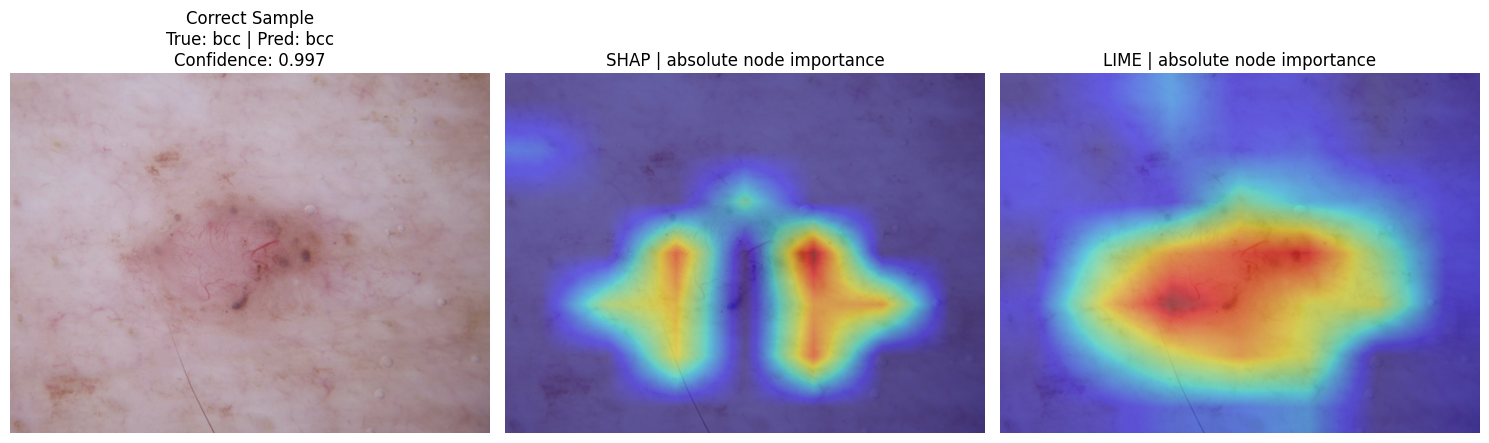


Explainability case: wrong


  0%|          | 0/1 [00:00<?, ?it/s]

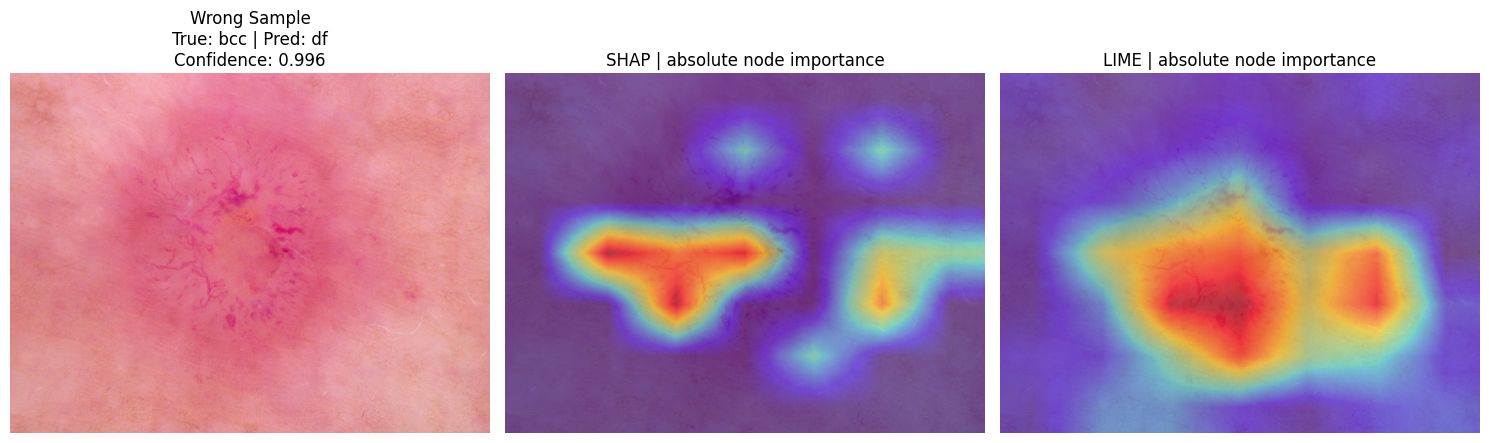

,case,image_id,lesion_id,true_class,predicted_class,confidence,figure_path
0,correct,ISIC_0028556,HAM_0002421,bcc,bcc,0.997243,/kaggle/working/task3_gnn_only/explainability/...
1,wrong,ISIC_0026528,HAM_0007550,bcc,df,0.996140,/kaggle/working/task3_gnn_only/explainability/...


In [38]:

def plot_explanation_case(
    case_name,
    row,
    shap_result,
    lime_result
):
    image = Image.open(
        row["path"]
    ).convert("RGB")

    image_array = np.asarray(
        image
    )

    shap_grid = (
        shap_result[
            "node_importance"
        ]
        .reshape(
            GRID_H,
            GRID_W
        )
    )

    lime_grid = (
        lime_result[
            "node_importance"
        ]
        .reshape(
            GRID_H,
            GRID_W
        )
    )

    shap_map = resize_importance_map(
        np.abs(shap_grid),
        image.width,
        image.height
    )

    lime_map = resize_importance_map(
        np.abs(lime_grid),
        image.width,
        image.height
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(
        image_array
    )
    axes[0].set_title(
        (
            f"{case_name.title()} Sample\n"
            f"True: {row['true_class']} | "
            f"Pred: {row['predicted_class']}\n"
            f"Confidence: {row['confidence']:.3f}"
        )
    )
    axes[0].axis("off")

    axes[1].imshow(
        image_array
    )
    axes[1].imshow(
        shap_map,
        alpha=0.50,
        cmap="jet"
    )
    axes[1].set_title(
        "SHAP | absolute node importance"
    )
    axes[1].axis("off")

    axes[2].imshow(
        image_array
    )
    axes[2].imshow(
        lime_map,
        alpha=0.50,
        cmap="jet"
    )
    axes[2].set_title(
        "LIME | absolute node importance"
    )
    axes[2].axis("off")

    plt.tight_layout()

    save_path = (
        EXPLAIN_DIR
        / f"{case_name}_shap_lime.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return save_path


explanation_records = []

for case_name, selected_row in [
    ("correct", correct_row),
    ("wrong", wrong_row)
]:
    print("\n" + "=" * 70)
    print(
        f"Explainability case: {case_name}"
    )
    print("=" * 70)

    shap_result = shap_node_explanation(
        selected_row["image_id"],
        final_model,
        nsamples=SHAP_NSAMPLES
    )

    lime_result = lime_node_explanation(
        selected_row["image_id"],
        final_model,
        num_samples=LIME_NUM_SAMPLES
    )

    figure_path = plot_explanation_case(
        case_name,
        selected_row,
        shap_result,
        lime_result
    )

    explanation_records.append({
        "case": case_name,
        "image_id": selected_row["image_id"],
        "lesion_id": selected_row["lesion_id"],
        "true_class": selected_row["true_class"],
        "predicted_class": selected_row["predicted_class"],
        "confidence": float(
            selected_row["confidence"]
        ),
        "figure_path": str(
            figure_path
        )
    })


explanation_summary_df = pd.DataFrame(
    explanation_records
)

explanation_summary_df.to_csv(
    EXPLAIN_DIR
    / "shap_lime_selected_samples.csv",
    index=False
)

display(
    explanation_summary_df
)



## 24. How to interpret the explainability figures

Use careful language.

### Correct sample
A suitable report interpretation is:

> SHAP and LIME identify spatial graph nodes that contributed most strongly to the Final GNN prediction. When high-importance regions overlap the lesion rather than surrounding background skin, this suggests that the classifier is relying on lesion-related visual representations.

### Wrong sample
A suitable interpretation is:

> In the misclassified example, the explanation highlights the spatial regions that influenced the incorrect prediction. Diffuse importance or emphasis on visually ambiguous regions may be associated with confusion between the true and predicted classes.

Do **not** claim:
- that SHAP/LIME provides causal proof,
- that the highlighted pixels are a medical lesion segmentation,
- that the explanation proves a clinical diagnosis.

These are post-hoc model explanations.



# Part K — Final Task-3 output summary


In [39]:

final_task3_summary = {
    "task": "Task 3 GNN-only improvement and explainability",
    "five_fold_gnn_cv": False,
    "split_unit": "lesion_id",
    "final_test_seed": FINAL_TEST_SEED,
    "train_images": int(len(train_df)),
    "validation_images": int(len(val_df)),
    "final_test_images": int(len(test_df)),
    "initial_gnn_config": INITIAL_GNN_CONFIG,
    "final_gnn_config": FINAL_GNN_CONFIG,
    "initial_gnn_test": {
        key: (
            None
            if (
                isinstance(value, float)
                and not np.isfinite(value)
            )
            else value
        )
        for key, value in initial_summary.items()
    },
    "final_gnn_test": {
        key: (
            None
            if (
                isinstance(value, float)
                and not np.isfinite(value)
            )
            else value
        )
        for key, value in final_summary.items()
    },
    "best_uploaded_baseline": BEST_BASELINE_NAME,
    "significance_test": significance_result,
    "bootstrap_iterations": 1000,
    "selection_metric": "validation Macro-F1",
    "baseline_models_modified": False
}

with open(
    RESULT_DIR / "task3_final_summary.json",
    "w"
) as file:
    json.dump(
        final_task3_summary,
        file,
        indent=4
    )

print("TASK 3 COMPLETE")
print("=" * 80)
print("Task-3 changes were applied only to the GNN.")
print("No GNN 5-fold CV was performed.")
print("The four uploaded baseline models were not modified.")
print("Final GNN selected using validation Macro-F1.")
print("Bootstrap 95% confidence intervals generated.")
print("Significance test generated.")
print("SHAP + LIME generated for one correct and one wrong sample.")
print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nImportant files:")
for path in [
    RESULT_DIR / "ablation_results.csv",
    RESULT_DIR / "final_gnn_config.json",
    RESULT_DIR / "final_gnn_test_predictions.csv",
    RESULT_DIR / "final_gnn_bootstrap_95ci.csv",
    RESULT_DIR / "baseline_and_gnn_comparison.csv",
    RESULT_DIR / "significance_test_vs_best_baseline.csv",
    EXPLAIN_DIR / "correct_shap_lime.png",
    EXPLAIN_DIR / "wrong_shap_lime.png",
    MODEL_DIR,
]:
    print(path)


TASK 3 COMPLETE
Task-3 changes were applied only to the GNN.
No GNN 5-fold CV was performed.
The four uploaded baseline models were not modified.
Final GNN selected using validation Macro-F1.
Bootstrap 95% confidence intervals generated.
Significance test generated.
SHAP + LIME generated for one correct and one wrong sample.

Output directory:
/kaggle/working/task3_gnn_only

Important files:
/kaggle/working/task3_gnn_only/results/ablation_results.csv
/kaggle/working/task3_gnn_only/results/final_gnn_config.json
/kaggle/working/task3_gnn_only/results/final_gnn_test_predictions.csv
/kaggle/working/task3_gnn_only/results/final_gnn_bootstrap_95ci.csv
/kaggle/working/task3_gnn_only/results/baseline_and_gnn_comparison.csv
/kaggle/working/task3_gnn_only/results/significance_test_vs_best_baseline.csv
/kaggle/working/task3_gnn_only/explainability/correct_shap_lime.png
/kaggle/working/task3_gnn_only/explainability/wrong_shap_lime.png
/kaggle/working/task3_gnn_only/models
